# 第四組第一次讀書會專案
組長：M144020045_房冠葦

組員：M144020062_郭倢圻、M144020016_簡以欣、M144020004_黃于庭、M144020053_滕冠廷、M144020071_蔡佳靜、M144020047_程善妮、M144020014_周宥呈

## 大綱
1.   專案動機與資料介紹
2.   航空文字雲
1.   lexicon-base情緒分析
2.   CKIP自然語言處理


### 1. 專案動機與資料介紹

*   動機：深入了解旅客對中華航空的真實看法，分析正負面評價的關鍵面向，作為後續改進服務品質的參考。

資料來源：

*   Tarflow爬取PPT 航空板資料
*   關鍵字：中華航空、華航
*   時間： 2025/01/01-2026/03/18
*   資料筆數：共 453 篇文章








In [ ]:
# 載入套件
import pandas as pd
import os
import jieba
import jieba.analyse
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap
%matplotlib inline

from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import time
import datetime

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:16: SyntaxWarning: invalid escape sequence '\.'
  re_skip_detail = re.compile("([\.0-9]+|[a-zA-Z0-9]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:17: SyntaxWarning: invalid escape sequence '\.'
  re_han_internal = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:18: SyntaxWarning: invalid escape sequence '\s'
  re_skip_internal = re.compil

In [ ]:
# 設定圖的字體大小
plt.rcParams['font.size'] = 14

# 設定圖的中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 中文字體

# 設定文字雲中文字體路徑
FontPath = 'SourceHanSansTW-Regular.otf' # 設定字型

# 設定整份 notebook 圖片的長寬與 dpi
plt.rcParams["figure.figsize"] = [6, 4]
plt.rcParams["figure.dpi"] = 120

載入資料集

In [ ]:
#讀入資料集
df = pd.read_csv('airplane.csv')
df.head()

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01 21:52:53,eden08062000,Aviation,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tannoy"", ""cm...",114.137.227.255,2025-01-02 01:00:41,ptt
1,2,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03 09:35:14,dimarzia,Aviation,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""alstonfju"", ...",222.250.148.74,2025-01-04 01:00:38,ptt
2,3,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,[分享]台北<->蒙特婁華航加航來回心得,2025-01-04 18:31:25,lilliant,Aviation,大家好，第一次在本版發文請見諒。原本我是要來本版求救，結果最後算是順利完成旅行\n，因此想來...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""mellopaw"", ""...",111.243.118.47,2025-01-05 01:00:40,ptt
3,4,https://www.ptt.cc/bbs/Aviation/M.1735998102.A...,[問題]有人去日本坐過日航嗎?,2025-01-04 21:41:39,aitt,Aviation,"五月計畫去東京,從松山坐到羽田,華航跟日航時間帶都不錯,\n一個9:00另一個9:30起飛,...","[{""cmtStatus"": ""推"", ""cmtPoster"": ""zoizupas"", ""...",95.173.197.87,2025-01-05 01:00:40,ptt
4,5,https://www.ptt.cc/bbs/Aviation/M.1736171133.A...,[分享]微軟當機航班取消，AirHelp代客申訴心得,2025-01-06 21:45:31,RachelMcAdam,Aviation,我在七月下旬從德國搭機回台，STR>FRA>TPE，漢莎航空接華航\n\nSTR>FRA是早...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""fman"", ""cmtC...",61.224.128.111,2025-01-07 01:00:41,ptt


## 2.航空文字雲
### 2.1 資料前處理
*   清除內文為空值的文章
*   將兩個換行取代為句號
*   清除不重要的字如換行、網址










In [ ]:
clear_df = df.copy()

#去除本次不會用到的欄位
drop_cols = ['system_id', 'artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource']
clear_df.drop(drop_cols, axis = 1, inplace = True)

#去除文章內容為空值的筆數
clear_df.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

# 轉換 artDate 只保留日期部分（去掉時間）
clear_df['artDate'] = pd.to_datetime(clear_df['artDate']).dt.date

#新增['sentence']欄位，用'。'取代'\n\n'，並移除'\n'
clear_df['sentence'] = clear_df['artContent'].str.replace(r'\n\n','。', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n','，', regex=True)

#移除內文中的網址
clear_df['sentence'] = clear_df['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df.head(10)

,artUrl,artTitle,artDate,artContent,sentence
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...
1,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,大家好。全段華航開票(同票號之一本票)。第一段CI9298 CDG-FRA(承運方：HOP航...
2,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,[分享]台北<->蒙特婁華航加航來回心得,2025-01-04,大家好，第一次在本版發文請見諒。原本我是要來本版求救，結果最後算是順利完成旅行\n，因此想來...,大家好，第一次在本版發文請見諒。原本我是要來本版求救，結果最後算是順利完成旅行，，因此想來分...
3,https://www.ptt.cc/bbs/Aviation/M.1735998102.A...,[問題]有人去日本坐過日航嗎?,2025-01-04,"五月計畫去東京,從松山坐到羽田,華航跟日航時間帶都不錯,\n一個9:00另一個9:30起飛,...","五月計畫去東京,從松山坐到羽田,華航跟日航時間帶都不錯,，一個9:00另一個9:30起飛,只..."
4,https://www.ptt.cc/bbs/Aviation/M.1736171133.A...,[分享]微軟當機航班取消，AirHelp代客申訴心得,2025-01-06,我在七月下旬從德國搭機回台，STR>FRA>TPE，漢莎航空接華航\n\nSTR>FRA是早...,我在七月下旬從德國搭機回台，STR>FRA>TPE，漢莎航空接華航。STR>FRA是早上七點...
5,https://www.ptt.cc/bbs/Aviation/M.1736241119.A...,[問題]華航飛美國西雅圖，運動器材,2025-01-07,請問華航飛美國西雅圖\n \n訂位兩人，額度有四托運行李與隨身行李\n \n行李有三大箱，ㄧ...,請問華航飛美國西雅圖， ，訂位兩人，額度有四托運行李與隨身行李， ，行李有三大箱，ㄧ裝箱洩氣...
6,https://www.ptt.cc/bbs/Aviation/M.1736266155.A...,[新聞]桃機出發日本特定機場1/16至2/12開放預,2025-01-08,自由 1/7\n桃機出發日本特定機場 1/16至2/12開放預先清關\n因應春節及寒假人潮，...,自由 1/7，桃機出發日本特定機場 1/16至2/12開放預先清關，因應春節及寒假人潮，為縮...
7,https://www.ptt.cc/bbs/Aviation/M.1736394527.A...,[新聞]大馬議員稱星宇檳城台北暫停飛旅遊局盼重啟,2025-01-09,中央社 2025/01/09\n大馬議員稱星宇檳城台北暫停飛 旅遊局盼重啟\n記者黃自強 吉...,中央社 2025/01/09，大馬議員稱星宇檳城台北暫停飛 旅遊局盼重啟，記者黃自強 吉隆坡...
8,https://www.ptt.cc/bbs/Aviation/M.1736519693.A...,[新聞]七大新航線揭幕！許智傑率交通部團隊考,2025-01-10,七大新航線揭幕！許智傑率交通部團隊 考察高雄重大交通建設\n\n2025年1月9日 台灣好報...,七大新航線揭幕！許智傑率交通部團隊 考察高雄重大交通建設。2025年1月9日 台灣好報。【記...
9,https://www.ptt.cc/bbs/Aviation/M.1736528623.A...,[問題]虎航託運行李單純計重量還是說也論件？,2025-01-11,我查了虎航官網實在看不太懂，這次買太多有加購重量，但是行李塞不下，東西太多。想日\n本買個便...,我查了虎航官網實在看不太懂，這次買太多有加購重量，但是行李塞不下，東西太多。想日，本買個便宜...


### 2.2斷句

In [ ]:
clear_df['sentence'] = clear_df['sentence'].str.split("[,，。！!？?;]{1,}")

sent_df = clear_df.explode('sentence').reset_index(drop=True)

sent_df.head(10)

,artUrl,artTitle,artDate,artContent,sentence
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,2024/12/31金卡到期
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合條件可以升等
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,但app還是一直舊資料的金卡
3,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,好奇是哪時才會
4,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,變動
5,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,
6,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,大家好
7,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,全段華航開票(同票號之一本票)
8,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,第一段CI9298 CDG-FRA(承運方：HOP航空)
9,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,第二段CI62 FRA-TPE(承運方：華航)


### 2.3斷詞

In [ ]:
jieba.set_dictionary('dict.txt')

#去除句子中除了字母、數字、空白字符以外的符號
sent_df['sentence'] = sent_df['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

sent_df.head(10)

,artUrl,artTitle,artDate,artContent,sentence
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231金卡到期
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合條件可以升等
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,但app還是一直舊資料的金卡
3,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,好奇是哪時才會
4,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,變動
6,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,大家好
7,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,全段華航開票同票號之一本票
8,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,第一段CI9298 CDGFRA承運方HOP航空
9,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,第二段CI62 FRATPE承運方華航
10,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,想請問若屆時第一段延誤 導致第二段失接


In [ ]:

word_df = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 去除空值
word_df = word_df.dropna(subset=['word'])

word_df.head(10)

,artUrl,artTitle,artDate,artContent,word
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,到期
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,條件
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,可以
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,升等
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,但
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,app
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,還是


### 2.4 計算去除停用字及更新字典前的詞頻並視覺化結果

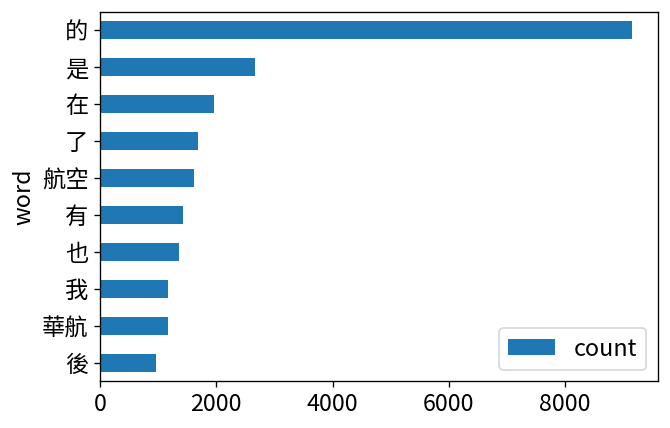

In [ ]:
word_df = word_df[word_df['word'].str.strip() != '']

freq_df = word_df['word'].value_counts().reset_index()
freq_df.columns = ['word', 'count']
freq_df = freq_df.sort_values(by=['count'], ascending=False)
freq_df.head(10)

freq_df.head(10).plot.barh(x = 'word', y = 'count').invert_yaxis()
plt.show()

In [ ]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict = freq_df.set_index('word').to_dict()
freq_dict = freq_dict['count']

print(dict(list(freq_dict.items())[:10]))

{'的': 9143, '是': 2666, '在': 1962, '了': 1682, '航空': 1622, '有': 1422, '也': 1361, '我': 1169, '華航': 1163, '後': 964}


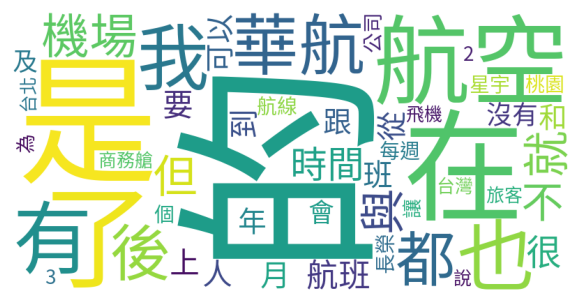

In [ ]:
# 繪製文字雲
wordcloud = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud.generate_from_frequencies(freq_dict)

plt.figure(figsize = (6,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
#去除少於兩個字的詞語
word_df = word_df.loc[word_df['word'].str.len() > 1]

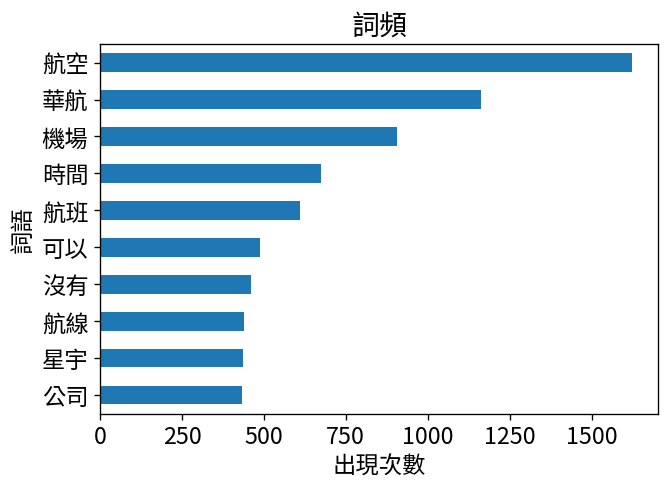

In [ ]:
# 產生詞頻 DataFrame
freq_df = word_df['word'].value_counts().reset_index()
freq_df.columns = ['word', 'count']
freq_df = freq_df.sort_values(by=['count'], ascending=False)

# 繪製長條圖
ax = freq_df.head(10).plot.barh(x='word', y='count', legend=False)
ax.invert_yaxis()  # 高first
plt.xlabel("出現次數")
plt.ylabel("詞語")
plt.title("詞頻")
plt.show()

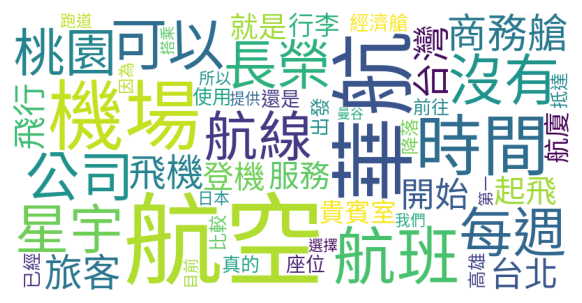

In [ ]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict = freq_df.set_index('word').to_dict()
freq_dict = freq_dict['count']

# 繪製文字雲
wordcloud_no1 = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud_no1.generate_from_frequencies(freq_dict)

plt.figure(figsize = (6,4))
plt.imshow(wordcloud_no1)
plt.axis('off')
plt.show()

### 2.5 移除停用字

In [ ]:
stopwords = [line.strip() for line in open('stopwords.txt', 'r', encoding='utf-8').readlines()]

In [ ]:
noStop_df = word_df[~word_df['word'].isin(stopwords)]

noStop_df.head(10)

,artUrl,artTitle,artDate,artContent,word
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,到期
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,條件
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,升等
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,app
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,一直
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,資料
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡


計算詞頻並繪製長條圖

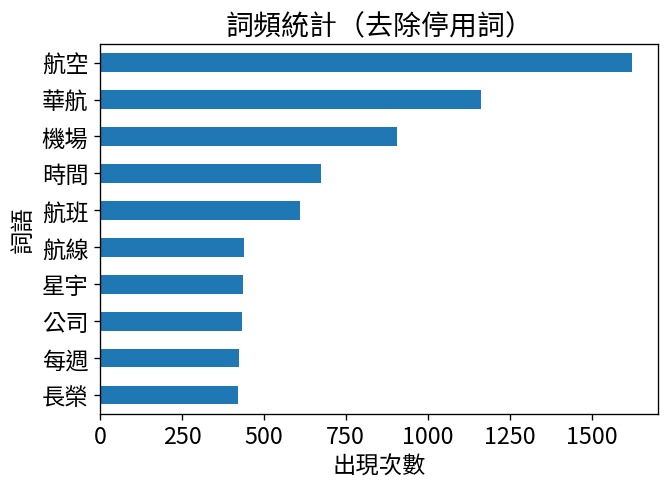

In [ ]:
# 產生詞頻 DataFrame
freq_df_nostop = noStop_df['word'].value_counts().reset_index()
freq_df_nostop.columns = ['word', 'count']  # 設定正確的欄位名稱
freq_df_nostop = freq_df_nostop.sort_values(by=['count'], ascending=False)  # 按次數排序

# 繪製水平長條圖
ax = freq_df_nostop.head(10).plot.barh(x='word', y='count', legend=False)
ax.invert_yaxis()  # 讓最高頻詞排在最上方
plt.xlabel("出現次數")
plt.ylabel("詞語")
plt.title("詞頻統計（去除停用詞）")
plt.show()

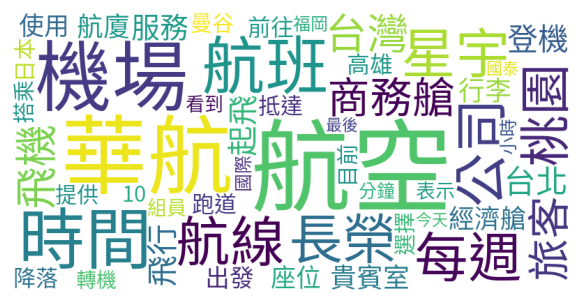

In [ ]:
freq_dict_nostop = freq_df_nostop.set_index('word').to_dict()
freq_dict_nostop = freq_dict_nostop['count']

# 繪製文字雲
wordcloud_nostop = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud_nostop.generate_from_frequencies(freq_dict_nostop)

plt.figure(figsize = (6,4))
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.show()

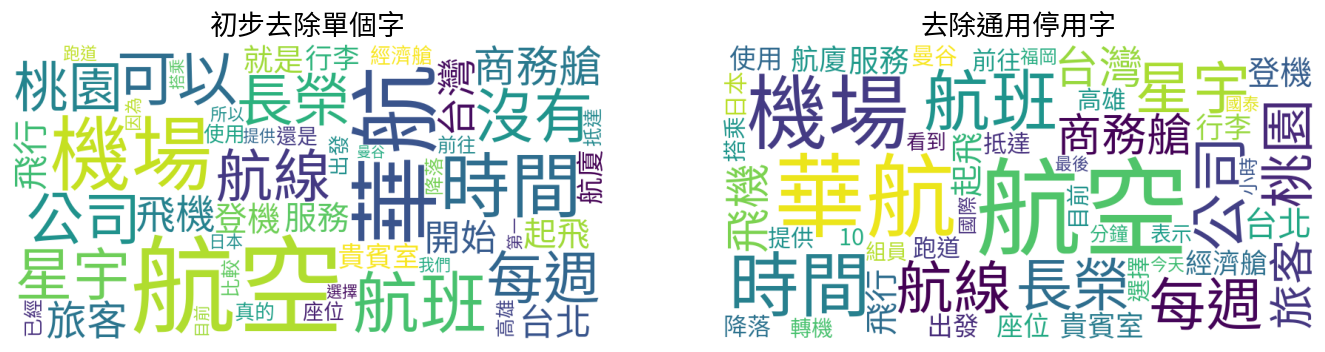

In [ ]:
plt.figure(figsize = (14,8))

plt.subplot(1,2,1)
plt.imshow(wordcloud_no1)
plt.axis('off')
plt.title("初步去除單個字")

plt.subplot(1,2,2)
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.title("去除通用停用字")

plt.show()

### 2.6 更新停用字字典

In [ ]:
stopwords_manual = [
    "航班", "班機", "飛機", "航線", "機場", "航廈", "TWD", "價格", "票價", "飛行", "星宇", "今天", "最後",
    "出發", "抵達", "起飛", "降落", "小時", "分鐘", "台灣", "台北", "桃園", "TPE", "公司", "每週", "長榮", "前往", "2025",
    "登機", "報到", "櫃檯", "機票", "來回", "單程", "旅客", "客人","中華航空", "華航", "China", "Airlines", "CI", "航空"
]

stopwords.extend(stopwords_manual)

In [ ]:
noStop_df_2 = noStop_df[~noStop_df['word'].isin(stopwords)]
noStop_df_2.head(10)

,artUrl,artTitle,artDate,artContent,word
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,到期
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,條件
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,升等
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,app
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,一直
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,資料
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡


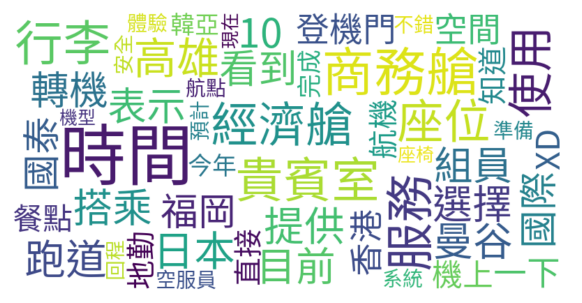

In [ ]:
# 計算詞頻
freq_df_nostop_2 = noStop_df_2['word'].value_counts().reset_index()
freq_df_nostop_2.columns = ['word', 'count']  # 設定正確的欄位名稱
freq_df_nostop_2 = freq_df_nostop_2.sort_values(by=['count'], ascending=False)  # 重新排序

# wordcloud 的輸入須為 dict，因此轉換 freq_df
freq_dict_nostop_2 = freq_df_nostop_2.set_index('word')['count'].to_dict()

# 繪製文字雲
wordcloud_nostop_2 = WordCloud(
    background_color='white',
    width=800,
    height=400,
    font_path=FontPath,
    max_words=50
).generate_from_frequencies(freq_dict_nostop_2)

plt.figure(figsize=(6,4))
plt.imshow(wordcloud_nostop_2, interpolation='bilinear')
plt.axis('off')
plt.show()

比較不同階段文字雲

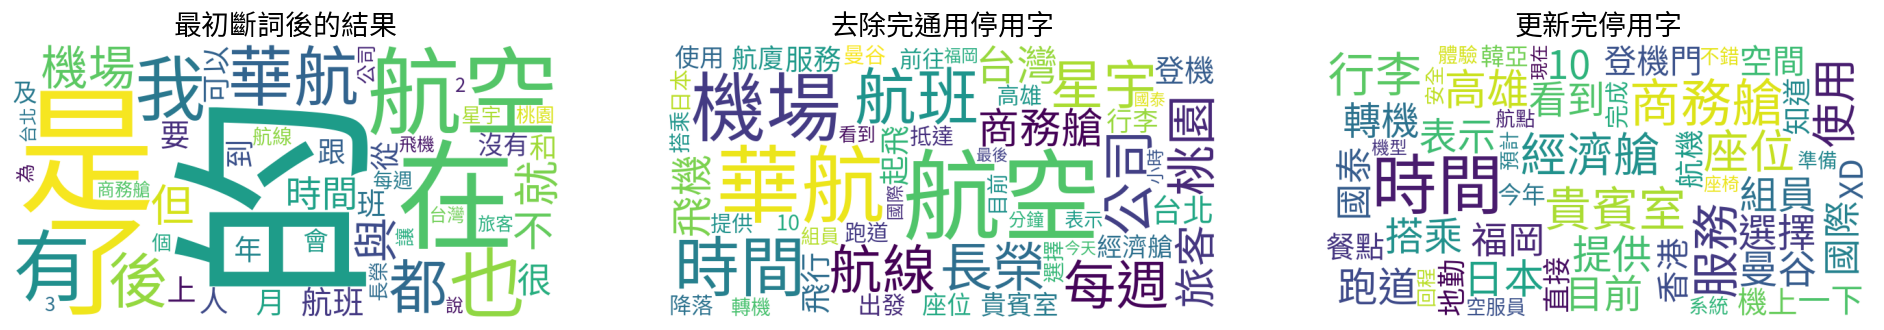

In [ ]:
plt.figure(figsize = (20,14))

plt.subplot(1,3,1)
plt.imshow(wordcloud)
plt.axis('off')
plt.title("最初斷詞後的結果")

plt.subplot(1,3,2)
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.title("去除完通用停用字")

plt.subplot(1,3,3)
plt.imshow(wordcloud_nostop_2)
plt.axis('off')
plt.title("更新完停用字")

plt.show()

結果顯示，旅客的討論焦點主要集中在『服務』、『貴賓室』、『商務艙』與『經濟艙』等與搭乘體驗密切相關的部分。

## 3.情緒分析
### 3.1 準備LIWC字典

In [ ]:
# 讀取情緒字典
liwc_dict = pd.read_csv("LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head()

,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


### 3.2 情緒字典與斷詞結果進行合併

In [ ]:
ptt_liwc_df = pd.merge(noStop_df_2, liwc_dict, how="left")
ptt_liwc_df.head()

,artUrl,artTitle,artDate,artContent,word,sentiments
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231,NaN
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡,NaN
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,到期,NaN
3,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合,NaN
4,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,條件,NaN


### 3.3 正負向情緒詞彙頻率折線圖
分別畫出資料集中，正向（positive）與負向（negative）情緒的折線圖

In [ ]:
sentiment_count = pd.DataFrame(
    ptt_liwc_df.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative")
sentiment_count = sentiment_count.loc[mask]

sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])
sentiment_count.head(10)

,artDate,sentiments,size
2,2025-01-01,negative,1
4,2025-01-03,positive,1
7,2025-01-04,negative,11
8,2025-01-04,positive,18
11,2025-01-06,negative,1
12,2025-01-06,positive,1
15,2025-01-07,negative,3
16,2025-01-07,positive,2
19,2025-01-08,positive,1
22,2025-01-09,negative,2


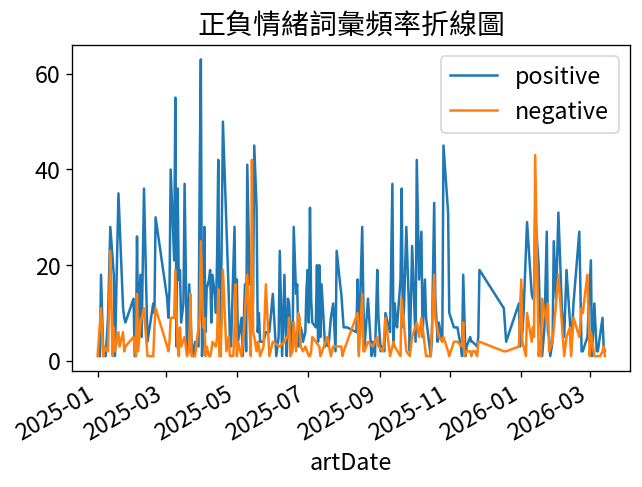

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

fig, ax = plt.subplots()

ax.plot(pos["artDate"], pos["size"], color=colors[0])
ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖")
plt.show()

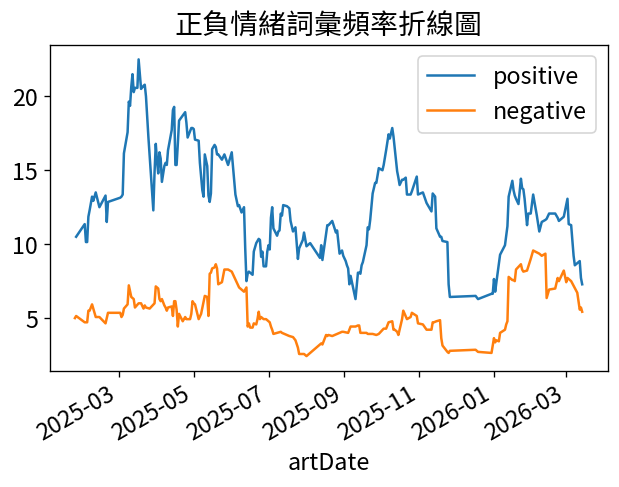

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖")
plt.show()

結果可看到正負向情緒詞彙的波動趨勢高度大部分一致，代表隨整體討論熱度起伏，但大部分正向情緒詞彙的出現頻率高於負向詞彙，顯示 PTT 航空版對於中華航空的整體討論氛圍是偏向正面的。

### 3.4 正負向情緒詞彙比例折線圖圖

In [ ]:
sentiment_count = sentiment_count.assign(
    ratio=sentiment_count.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_count.head(10)

,artDate,sentiments,size,ratio
2,2025-01-01,negative,1,1.000000
4,2025-01-03,positive,1,1.000000
7,2025-01-04,negative,11,0.379310
8,2025-01-04,positive,18,0.620690
11,2025-01-06,negative,1,0.500000
12,2025-01-06,positive,1,0.500000
15,2025-01-07,negative,3,0.600000
16,2025-01-07,positive,2,0.400000
19,2025-01-08,positive,1,1.000000
22,2025-01-09,negative,2,0.285714


In [ ]:
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

Text(0.5, 1.0, '正負情緒比例折線圖')

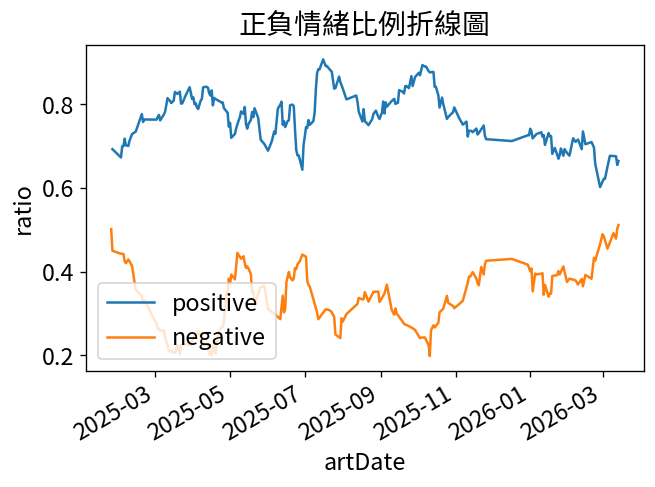

In [ ]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(pos["artDate"], pos["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("正負情緒比例折線圖")

雖然有部分時間負面情緒詞彙比例接近0.5，但大部分都位於0.5以下，表示討論還是偏向正面。

### 3.5 正負向情緒分數折線圖

In [ ]:
sentiment_count.head(10)

,artDate,sentiments,size,ratio
2,2025-01-01,negative,1,1.000000
4,2025-01-03,positive,1,1.000000
7,2025-01-04,negative,11,0.379310
8,2025-01-04,positive,18,0.620690
11,2025-01-06,negative,1,0.500000
12,2025-01-06,positive,1,0.500000
15,2025-01-07,negative,3,0.600000
16,2025-01-07,positive,2,0.400000
19,2025-01-08,positive,1,1.000000
22,2025-01-09,negative,2,0.285714


In [ ]:
ptt_sentiment_value = (
    sentiment_count.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value.head()

,artDate,negative,positive
0,2025-01-01,1.0,0.0
1,2025-01-03,0.0,1.0
2,2025-01-04,11.0,18.0
3,2025-01-06,1.0,1.0
4,2025-01-07,3.0,2.0


In [ ]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value["sentiment_value"] = (
    ptt_sentiment_value["positive"]
    - ptt_sentiment_value["negative"]
)
ptt_sentiment_value.head()

,artDate,negative,positive,sentiment_value
0,2025-01-01,1.0,0.0,-1.0
1,2025-01-03,0.0,1.0,1.0
2,2025-01-04,11.0,18.0,7.0
3,2025-01-06,1.0,1.0,0.0
4,2025-01-07,3.0,2.0,-1.0


Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

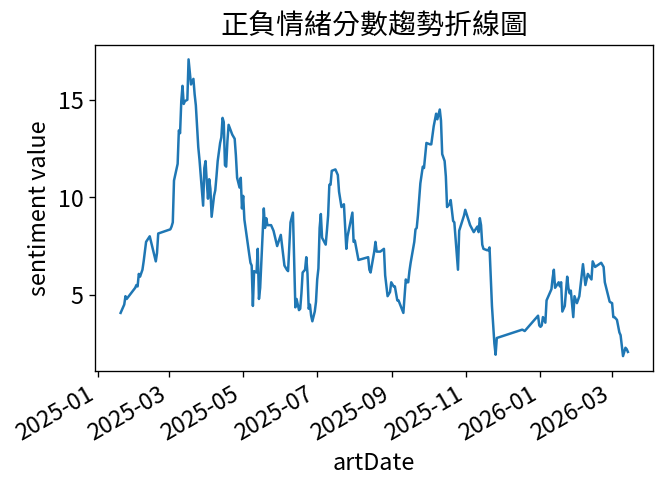

In [ ]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(ptt_sentiment_value["artDate"], ptt_sentiment_value["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖")

### 3.6 文章為單位的情緒分析

In [ ]:
sentiment_count_by_article = pd.DataFrame(
    ptt_liwc_df.groupby(["artUrl", "sentiments"]).size()
).reset_index()
sentiment_count_by_article = sentiment_count_by_article.rename(columns={0: "size"})
sentiment_count_by_article.head(10)

,artUrl,sentiments,size
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,affect,1
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,anx,1
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,negative,1
3,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,affect,1
4,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,positive,1
5,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,affect,27
6,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,anx,5
7,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,negative,11
8,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,positive,17
9,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,sad,3


In [ ]:
ptt_sentiment_value_by_article = (
    sentiment_count_by_article.pivot_table(
        index="artUrl", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value_by_article.head()

,artUrl,affect,anger,anx,negative,positive,sad
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,1.0,0.0,1.0,1.0,0.0,0.0
1,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,1.0,0.0,0.0,0.0,1.0,0.0
2,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,27.0,0.0,5.0,11.0,17.0,3.0
3,https://www.ptt.cc/bbs/Aviation/M.1735998102.A...,1.0,0.0,0.0,0.0,1.0,0.0
4,https://www.ptt.cc/bbs/Aviation/M.1736171133.A...,3.0,0.0,0.0,1.0,1.0,0.0


sentiment分數可看出文章多正面，或多負面

In [ ]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value_by_article["sentiment_value"] = (
    ptt_sentiment_value_by_article["positive"]
    - ptt_sentiment_value_by_article["negative"]
)
ptt_sentiment_value_by_article.head()

,artUrl,affect,anger,anx,negative,positive,sad,sentiment_value
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,1.0,0.0,1.0,1.0,0.0,0.0,-1.0
1,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,27.0,0.0,5.0,11.0,17.0,3.0,6.0
3,https://www.ptt.cc/bbs/Aviation/M.1735998102.A...,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,https://www.ptt.cc/bbs/Aviation/M.1736171133.A...,3.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
ptt_sentiment_value_by_article['sentiment_class'] = ptt_sentiment_value_by_article['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )
ptt_sentiment_value_by_article.head(10)

,artUrl,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,1.0,0.0,1.0,1.0,0.0,0.0,-1.0,負向
1,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
2,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,27.0,0.0,5.0,11.0,17.0,3.0,6.0,正向
3,https://www.ptt.cc/bbs/Aviation/M.1735998102.A...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
4,https://www.ptt.cc/bbs/Aviation/M.1736171133.A...,3.0,0.0,0.0,1.0,1.0,0.0,0.0,負向
5,https://www.ptt.cc/bbs/Aviation/M.1736241119.A...,5.0,0.0,1.0,3.0,2.0,1.0,-1.0,負向
6,https://www.ptt.cc/bbs/Aviation/M.1736266155.A...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
7,https://www.ptt.cc/bbs/Aviation/M.1736394527.A...,7.0,1.0,0.0,2.0,5.0,2.0,3.0,正向
8,https://www.ptt.cc/bbs/Aviation/M.1736519693.A...,11.0,0.0,1.0,2.0,9.0,1.0,7.0,正向
9,https://www.ptt.cc/bbs/Aviation/M.1736649711.A...,15.0,1.0,1.0,12.0,1.0,3.0,-11.0,負向


In [ ]:
# 各文章標示情緒
clear_df_sentiment = pd.merge(df, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
clear_df_sentiment["artDate"] = pd.to_datetime(clear_df_sentiment["artDate"])
clear_df_sentiment['artDate'] = clear_df_sentiment['artDate'].dt.date

clear_df_sentiment.head()

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,sentiment_class
0,1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,eden08062000,Aviation,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tannoy"", ""cm...",114.137.227.255,2025-01-02 01:00:41,ptt,負向
1,2,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03,dimarzia,Aviation,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""alstonfju"", ...",222.250.148.74,2025-01-04 01:00:38,ptt,正向
2,3,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,[分享]台北<->蒙特婁華航加航來回心得,2025-01-04,lilliant,Aviation,大家好，第一次在本版發文請見諒。原本我是要來本版求救，結果最後算是順利完成旅行\n，因此想來...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""mellopaw"", ""...",111.243.118.47,2025-01-05 01:00:40,ptt,正向
3,4,https://www.ptt.cc/bbs/Aviation/M.1735998102.A...,[問題]有人去日本坐過日航嗎?,2025-01-04,aitt,Aviation,"五月計畫去東京,從松山坐到羽田,華航跟日航時間帶都不錯,\n一個9:00另一個9:30起飛,...","[{""cmtStatus"": ""推"", ""cmtPoster"": ""zoizupas"", ""...",95.173.197.87,2025-01-05 01:00:40,ptt,正向
4,5,https://www.ptt.cc/bbs/Aviation/M.1736171133.A...,[分享]微軟當機航班取消，AirHelp代客申訴心得,2025-01-06,RachelMcAdam,Aviation,我在七月下旬從德國搭機回台，STR>FRA>TPE，漢莎航空接華航\n\nSTR>FRA是早...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""fman"", ""cmtC...",61.224.128.111,2025-01-07 01:00:41,ptt,負向


In [ ]:
# 留下日期、情緒
sentiment_art_count = pd.DataFrame(
    clear_df_sentiment.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_art_count = sentiment_art_count.rename(columns={0: "size"})
sentiment_art_count = sentiment_art_count.sort_values(["artDate"])
sentiment_art_count

,artDate,sentiment_class,size
0,2025-01-01,負向,1
1,2025-01-03,正向,1
2,2025-01-04,正向,2
3,2025-01-06,負向,1
4,2025-01-07,負向,1
...,...,...,...
282,2026-03-10,負向,1
283,2026-03-12,正向,1
284,2026-03-13,負向,1
285,2026-03-14,正向,1


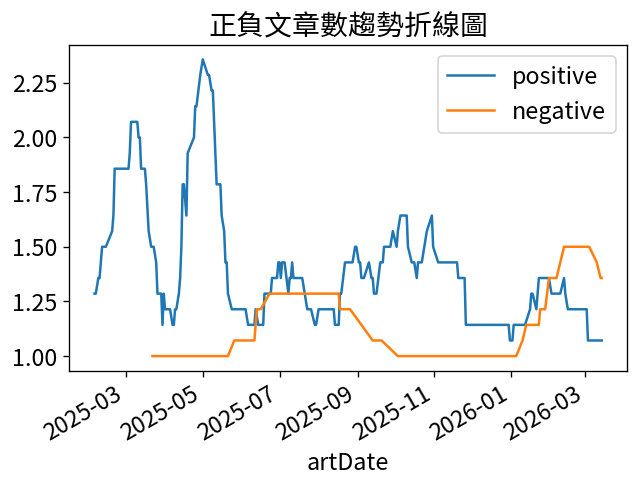

In [ ]:
# 計算14天正負面個別的平均文章數量
colors = ["tab:blue", "tab:orange"]
pos = sentiment_art_count[sentiment_art_count["sentiment_class"] == "正向"]
neg = sentiment_art_count[sentiment_art_count["sentiment_class"] == "負向"]

fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負文章數趨勢折線圖")
plt.show()

大部分時間正向文章數量都比負面文章多，但也有一些時間段的負面文章數量較多，可藉由這張圖特別關注當時是否有重大時事發生。


In [ ]:
import datetime

start_date = datetime.date(2026, 2, 18)
end_date = datetime.date(2026, 3, 18)

condition = (
    (clear_df_sentiment['artDate'] >= start_date) &
    (clear_df_sentiment['artDate'] <= end_date) &
    (clear_df_sentiment['sentiment_class'] == '負向')
)

negative_posts_march = clear_df_sentiment[condition]

print(f"這段期間共有 {len(negative_posts_march)} 篇負面文章。")

negative_posts_march[['artDate', 'artTitle', 'artUrl']].head(10)

這段期間共有 8 篇負面文章。


,artDate,artTitle,artUrl
433,2026-02-22,[新聞]娶空姐又偷吃空姐！ 副機師告華航慘吞敗,https://www.ptt.cc/bbs/Aviation/M.1771723668.A...
434,2026-02-23,[水桶]cityport,https://www.ptt.cc/bbs/Aviation/M.1771817675.A...
436,2026-02-27,[問題]為了預約兒童餐華航KML互踢皮球,https://www.ptt.cc/bbs/Aviation/M.1772159208.A...
437,2026-03-01,[新聞]中東戰火影響「桃機今8航班取消」業者：,https://www.ptt.cc/bbs/Aviation/M.1772328710.A...
441,2026-03-04,[問題]虹橋機場國際轉國內問題,https://www.ptt.cc/bbs/Aviation/M.1772610486.A...
446,2026-03-10,Re:[情報]星宇航空增租A321neo/減租A330neo,https://www.ptt.cc/bbs/Aviation/M.1773143347.A...
449,2026-03-13,[新聞]卓榮泰秀赴日4單據包機208萬全程總計約2,https://www.ptt.cc/bbs/Aviation/M.1773379554.A...
451,2026-03-14,[閒聊]關於會籍匹配,https://www.ptt.cc/bbs/Aviation/M.1773483162.A...


列出負面文章較多的時段的負面貼文

### 3.7 情緒代表字

In [ ]:
# 所有情緒代表字
word_count = ptt_liwc_df.groupby(["word", "sentiments"]).size().reset_index()
word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_count.head(10)

,word,sentiments,size
43,不錯,positive,142
42,不錯,affect,142
383,安全,affect,137
384,安全,positive,137
270,問題,negative,115
269,問題,affect,115
381,娛樂,affect,84
382,娛樂,positive,84
362,好吃,positive,79
361,好吃,affect,79


In [ ]:
# 正面情緒代表字
word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_pos.head(15)

,word,sentiments,size
43,不錯,positive,142
384,安全,positive,137
382,娛樂,positive,84
362,好吃,positive,79
147,免費,positive,72
571,感謝,positive,72
278,喜歡,positive,63
445,希望,positive,61
786,歡迎,positive,58
1116,舒適,positive,56


In [ ]:
# 負面情緒代表字
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]
word_of_neg.head(15)

,word,sentiments,size
270,問題,negative,115
37,不足,negative,24
675,擔心,negative,24
1272,降低,negative,21
319,壓力,negative,21
705,故障,negative,20
1146,虧損,negative,18
695,放下,negative,18
296,嚴重,negative,17
956,異常,negative,16


/tmp/ipykernel_1038/834213686.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"])
/tmp/ipykernel_1038/834213686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"])


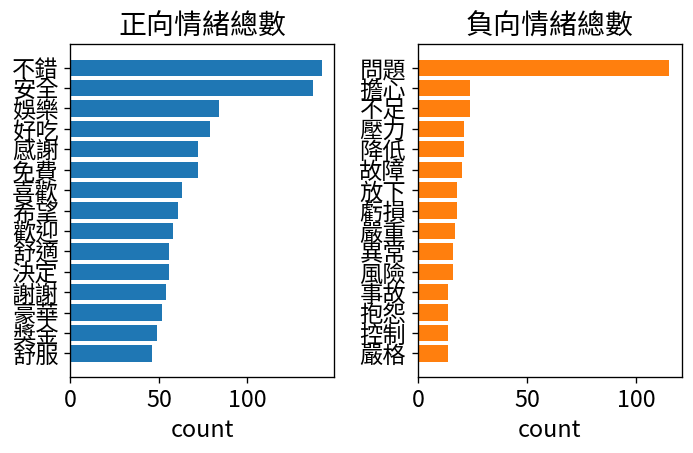

In [ ]:
# 計算正負面個別情緒代表字總數
pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"])
ax[0].set_title("正向情緒總數")

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"])
ax[1].set_title("負向情緒總數")

plt.tight_layout()

### 檢查情緒詞是否符合本文本

『嚴格』一詞不一定是負面，因此進一步進行分析。

In [ ]:
filtered_df = sent_df[sent_df['sentence'].str.contains('嚴格', na=False)]
filtered_df.head()

,artUrl,artTitle,artDate,artContent,sentence
3881,https://www.ptt.cc/bbs/Aviation/M.1741111806.A...,Re:[新聞]長榮:3月起全航班全程禁用行動電源,2025-03-05,3/1新規上路較為混亂，目前看仁川、釜山、濟州各機場回報：\n1.報到時，地勤會詢問是否攜帶...,不一定嚴格執行
6513,https://www.ptt.cc/bbs/Aviation/M.1742586943.A...,[分享]歐羅巴航空葡萄牙波多→西班牙馬德里,2025-03-22,有圖有起降影片好讀網誌版\nhttps://lion1227.pixnet.net/blog...,地勤人員非常嚴格的實施各艙等分流登機
7930,https://www.ptt.cc/bbs/Aviation/M.1743576582.A...,[新聞]台灣國籍航空告別「空姐只能穿裙子」的,2025-04-02,Yahoo新聞 2025年4月2日 週三 上午8:01\n台灣國籍航空告別「空姐只能穿裙子」...,對女性空服員更採取嚴格的父權管理方式
13150,https://www.ptt.cc/bbs/Aviation/M.1746864312.A...,[分享]20250319OZ712TPE-ICNA380飛行紀錄,2025-05-10,今年三月的九州行，本欲從高雄出發，但查完長榮魚肉鄉民的價格後，\n\n決定從桃園啟程，也意外...,嚴格禁止在飛機上使用行動電源
13913,https://www.ptt.cc/bbs/Aviation/M.1747297258.A...,[分享]華航CI62FRA-TPEA350-900經濟艙,2025-05-15,圖文並茂連結:\nhttps://noahleeeee.blogspot.com/2025/...,他們很嚴格地要


In [ ]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

不一定嚴格執行
地勤人員非常嚴格的實施各艙等分流登機
對女性空服員更採取嚴格的父權管理方式
嚴格禁止在飛機上使用行動電源
他們很嚴格地要
我國另外有部分規範相對嚴格
嚴格落實人員執行相關作業程序5月24日
可能因為成本預算嚴格管控
所有豬肉原料皆經嚴格把關
 泗水CI751CI752 嚴格來說SUB不是因為疫情停飛的
嚴格印度素與水果餐分享
這趟我預點未在早餐時段吃過的嚴格印度素食餐
是因為廉航嚴格控管成本
三家的共同點都是嚴格控制成本


『謝謝』一詞不一定是正面，因此進一步進行分析。

In [ ]:
filtered_df = sent_df[sent_df['sentence'].str.contains('謝謝', na=False)]
filtered_df.head()

,artUrl,artTitle,artDate,artContent,sentence
240,https://www.ptt.cc/bbs/Aviation/M.1736241119.A...,[問題]華航飛美國西雅圖，運動器材,2025-01-07,請問華航飛美國西雅圖\n \n訂位兩人，額度有四托運行李與隨身行李\n \n行李有三大箱，ㄧ...,謝謝
832,https://www.ptt.cc/bbs/Aviation/M.1736931849.A...,[分享]日航JL37B77WHND-SIN頭等艙飛行紀錄下,2025-01-15,好讀圖文版\nhttps://vocus.cc/article/6784700afd8978...,真是謝謝另外六位紳士髀
3167,https://www.ptt.cc/bbs/Aviation/M.1739971655.A...,[票務]華航機票被取消,2025-02-19,[航空公司]:華航\n\n\n[購買途徑]:官網\n\n\n[班機日期]:2025.2.21...,謝謝
3181,https://www.ptt.cc/bbs/Aviation/M.1740012770.A...,[問題]中信華航聯名卡優先報到登機?,2025-02-20,小弟因這兩年很常出差日本 加上搭華航機率比較高\n\n單純想要優先報到跟登機\n\n就去辦最...,謝謝
5058,https://www.ptt.cc/bbs/Aviation/M.1741500725.A...,[分享]20241230MM32KHH-KIXA321LR初體驗,2025-03-09,去年年底的跨年之旅，千挑萬選後意外與樂桃菜續前緣，\n\n相對便宜的票價，舒適的A321LR...,謝謝


In [ ]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

謝謝
真是謝謝另外六位紳士髀
謝謝
謝謝
謝謝
謝謝各位回答
謝謝
謝謝解惑
9天前差強人意的胡同馬告台灣鹹豬肉佐刺蔥飯謝謝
謝謝
謝謝
得到了來自移民官的中文謝謝
兩本票轉機的機場不多 不知道以上資訊是否正確 謝謝
謝謝老婆讓我一人坐在走道的另外一側
資料若有錯誤請再推文告知 謝謝
謝謝
資料若有誤 再請推文告知 謝謝
謝謝
謝謝
謝謝各位
謝謝
謝謝
謝謝
謝謝
謝謝回覆
謝謝
謝謝
謝謝
謝謝
謝謝
問題結束  謝謝
謝謝解答跟討論
謝謝
謝謝
先謝謝大家的意見
謝謝
謝謝
謝謝大家的幫忙
謝謝
謝謝大家
謝謝
謝謝
我太好了XD謝謝
謝謝收看
謝謝
謝謝有機會再來試看看
謝謝
謝謝
謝謝
謝謝
謝謝
還是謝謝你
謝謝大家收看
謝謝


### 重新計算情緒
控管、控制、規範、實施、執行、把關、分享

In [ ]:
# 設定要移除的字詞列表
words_to_remove = ['控管','控制','規範','實施','執行','把關','負擔','分享']
# 使用 ~ 運算子和 isin() 方法過濾掉包含在 words_to_remove 列表中的行
liwc_dict_revise = liwc_dict[~liwc_dict['word'].isin(words_to_remove)]
# 使用更新後的情緒字典 merge
ptt_liwc_df_revise = pd.merge(noStop_df[["artUrl", "artDate", "artTitle", "artContent","word"]], liwc_dict_revise, how="left")
ptt_liwc_df_revise.head()

,artUrl,artDate,artTitle,artContent,word,sentiments
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231,NaN
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡,NaN
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,到期,NaN
3,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合,NaN
4,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,條件,NaN


/tmp/ipykernel_1038/3563277495.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"])
/tmp/ipykernel_1038/3563277495.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"])


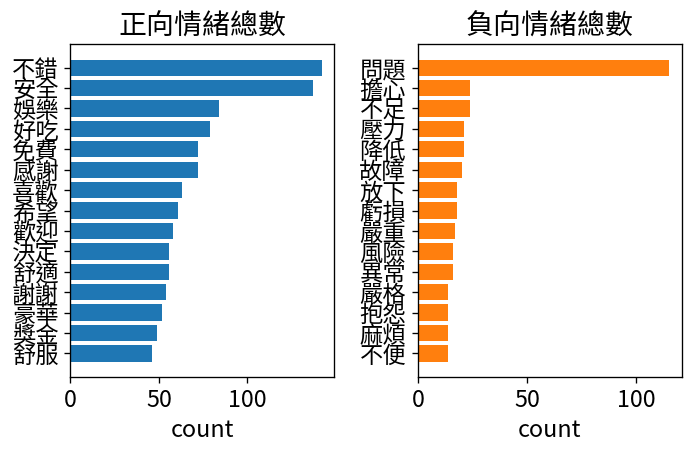

In [ ]:
# 重新計算正負面個別情緒代表字總數
word_count = ptt_liwc_df_revise.groupby(["word", "sentiments"]).size().reset_index()

word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]

pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"])
ax[0].set_title("正向情緒總數")

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"])
ax[1].set_title("負向情緒總數")

plt.tight_layout()

### 重新繪製情緒分數趨勢圖

Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

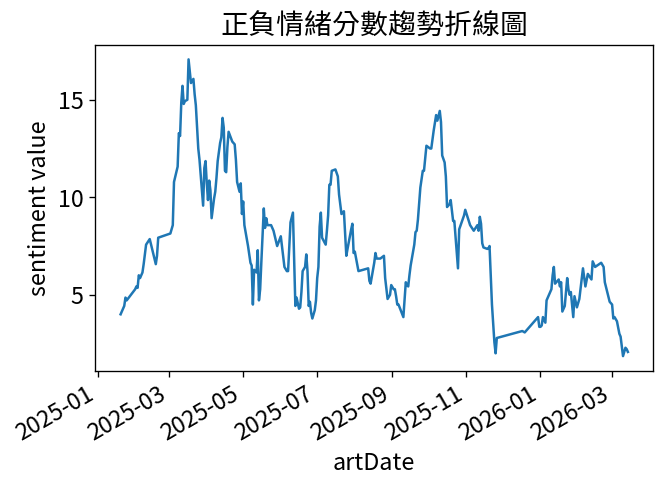

In [ ]:
sentiment_count_revise = pd.DataFrame(
    ptt_liwc_df_revise.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count_revise['sentiments'] == "positive") | (sentiment_count_revise['sentiments'] == "negative")
sentiment_count_revise = sentiment_count_revise.loc[mask]

sentiment_count_revise = sentiment_count_revise.rename(columns={0: "size"})
sentiment_count_revise = sentiment_count_revise.sort_values(["artDate"])

ptt_sentiment_value_revise = (
    sentiment_count_revise.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# sentiment 計算方式: positive - negative
ptt_sentiment_value_revise["sentiment_value"] = (
    ptt_sentiment_value_revise["positive"]
    - ptt_sentiment_value_revise["negative"]
)

# 繪製情緒分數趨勢圖
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(ptt_sentiment_value_revise["artDate"], ptt_sentiment_value_revise["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖")

### 3.8 文字雲


In [ ]:
# 將前面計算出的文章情緒類別合併，以利過濾出正面文章資料(以詞彙為單位)
ptt_liwc_df_revise = pd.merge(ptt_liwc_df_revise, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
ptt_liwc_df_revise.head()

,artUrl,artDate,artTitle,artContent,word,sentiments,sentiment_class
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231,NaN,負向
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,金卡,NaN,負向
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,到期,NaN,負向
3,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合,NaN,負向
4,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,2025-01-01,[問題]華航金卡問題,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,條件,NaN,負向


In [ ]:
# 將前面計算出的文章情緒類別合併，以利過濾出正面文章資料(以句子為單位)
sent_df = pd.merge(sent_df, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
sent_df.head()

,artUrl,artTitle,artDate,artContent,sentence,sentiment_class
0,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,20241231金卡到期,負向
1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,符合條件可以升等,負向
2,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,但app還是一直舊資料的金卡,負向
3,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,好奇是哪時才會,負向
4,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,變動,負向


In [ ]:
# 抓出正面文章
date = "2025-10-01"
end_date = "2026-03-18"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask]
ptt_df_wc.head(10)

,artUrl,artDate,artTitle,artContent,word,sentiments,sentiment_class
92969,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,平常,NaN,正向
92970,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,航空,NaN,正向
92971,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,算是,NaN,正向
92972,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,小有,NaN,正向
92973,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,研究,NaN,正向
92974,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,分享,NaN,正向
92975,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,西南,NaN,正向
92976,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,航空,NaN,正向
92977,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,結盟,NaN,正向
92978,https://www.ptt.cc/bbs/Aviation/M.1759375646.A...,2025-10-02,[分享]華航與西南航空結盟北美新動線的好處?,平常在航空算是小有研究，來跟大家分享跟西南航空結盟會有什麼好處？\n小的小小分析還請小力噴。...,會有,NaN,正向


In [ ]:
# 抓出正面詞彙
date = "2025-10-01"
end_date = "2026-03-18"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["artDate", "word"]]


word_count_count = pd.DataFrame(
    ptt_df_wc.groupby(["word"]).size()
).reset_index().rename(columns={0: "size"})

word_count_count = word_count_count.sort_values(by='size', ascending=False)
word_count_count.head(10)

,word,size
7919,航空,327
8011,華航,259
6260,機場,168
5908,時間,152
3995,商務艙,126
7917,航班,119
5861,星宇,119
3350,公司,115
9122,長榮,110
5789,旅客,94


(np.float64(-0.5), np.float64(1599.5), np.float64(799.5), np.float64(-0.5))

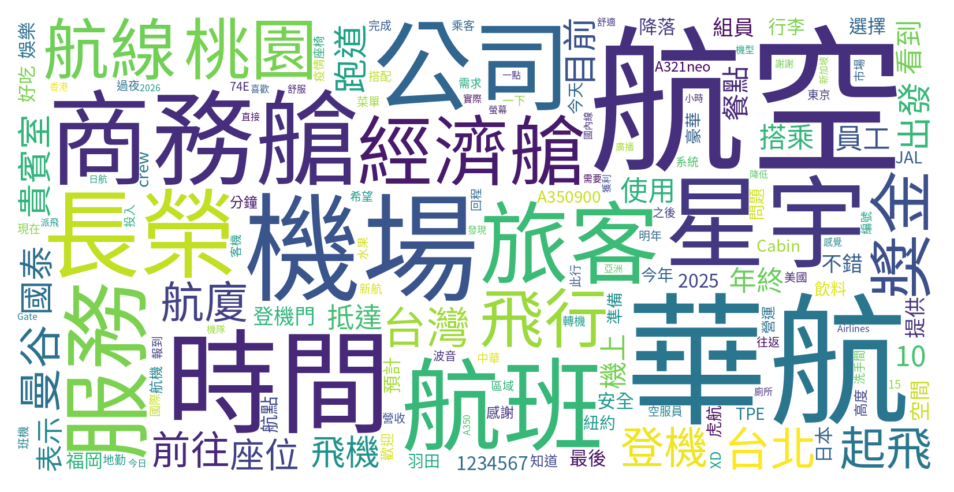

In [ ]:
# 繪製文字雲
# wordcloud 的 input 是 dictionary
font_path = "SourceHanSansTW-Regular.otf"  # 中文字型路徑
wc_dict = dict(zip(word_count_count['word'], word_count_count['size']))
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path)
cloud.generate_from_frequencies(wc_dict)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
# plt.show()

(np.float64(-0.5), np.float64(1599.5), np.float64(799.5), np.float64(-0.5))

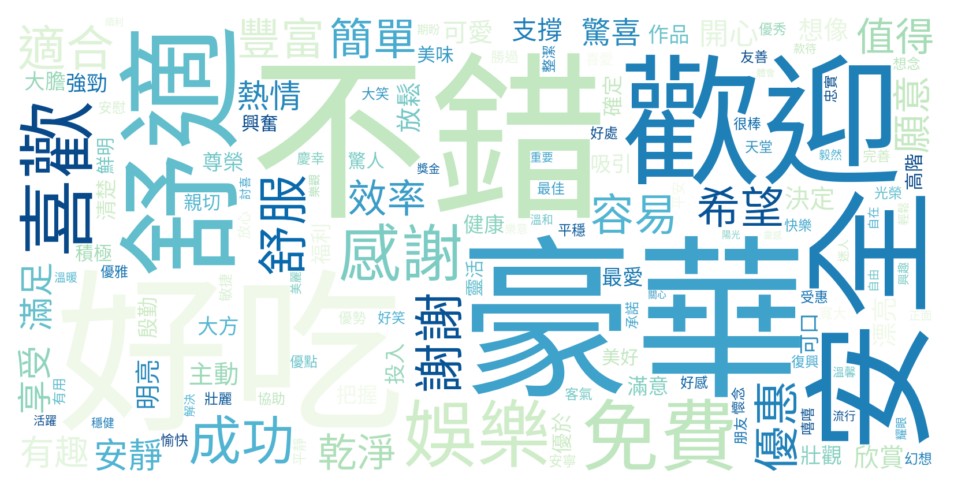

In [ ]:
# 以關鍵字"商務艙"繪製正面文字雲
date = "2025-10-01"
end_date = "2026-03-18"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")  & (
    ptt_liwc_df_revise['artContent'].str.contains('商務艙')) & (
    ptt_liwc_df_revise["sentiments"] == "positive")

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["artDate", "word"]]
wc = ptt_df_wc.groupby(["word"]).size().to_dict()

# wordcloud 的 input 是 dictionary
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path, colormap="GnBu")
cloud.generate_from_frequencies(wc)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(
    cloud,
    interpolation="bilinear"
)
plt.axis("off")
# plt.show()

In [ ]:
# 列出包含"商務艙"的所有句子中，包含"好吃"詞彙的句子
date = "2025-10-01"
end_date = "2026-03-18"
mask = (sent_df['artDate'] >= pd.Timestamp(date).date()) & (
    sent_df['artDate'] <= pd.Timestamp(end_date).date()) & (
    sent_df['sentiment_class'] == "正向") & (
    sent_df['artContent'].str.contains('商務艙')) & (
    sent_df['sentence'].str.contains('好吃'))

df_ = sent_df.loc[mask, ["artDate", "artContent", "sentence"]]
index_list = df_.index.tolist()


# 取得前後各5筆的索引 => 目的為查看包含該詞彙句子的上下文
surrounding_indices = []
for index in index_list:
    surrounding_indices.extend(range(index - 5, index + 6))

# 去除重複的索引，並確保不超出範圍
surrounding_indices = list(set(filter(lambda x: x >= 0 and x < len(sent_df), surrounding_indices)))

# 依據索引取得相應的資料
result_df = sent_df.iloc[surrounding_indices].sort_index()
result_df[['artTitle', 'sentence', 'sentiment_class']]

,artTitle,sentence,sentiment_class
23552,[分享]20250829SQ247新航A359商務艙SIN-MEL,我選了日本和牛飯,正向
23553,[分享]20250829SQ247新航A359商務艙SIN-MEL,姐姐則是選了龍蝦,正向
23554,[分享]20250829SQ247新航A359商務艙SIN-MEL,這一道是前菜,正向
23555,[分享]20250829SQ247新航A359商務艙SIN-MEL,雞肉沙嗲,正向
23556,[分享]20250829SQ247新航A359商務艙SIN-MEL,我的和牛白飯,正向
...,...,...,...
32767,[分享]中華航空CI501TPE-PVG777飛行記錄,真的是無懈可,正向
32768,[分享]中華航空CI501TPE-PVG777飛行記錄,擊的五星級感受了,正向
32769,[分享]中華航空CI501TPE-PVG777飛行記錄,吃完飯滑滑個人電視發現已經秀出轉程航班資訊,正向
32770,[分享]中華航空CI501TPE-PVG777飛行記錄,但內容有點陽春,正向


根據文章可看出，許多民眾對於商務艙的食物表達正面評價

## 4 CKIP自然語言處理

### 4.1 CKIP安裝

In [ ]:
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import re
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime

In [ ]:
data_utils.download_data_gdown("./")  # 下載ckip model

Downloading...
From (original): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771
From (redirected): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771&confirm=t&uuid=078c4c63-3a8e-41ec-a421-7668384bdaf8
To: /content/drive/MyDrive/Colab_Notebooks/社群媒體分析/專案一_航空/data.zip
100%|██████████| 1.88G/1.88G [00:30<00:00, 60.6MB/s]


In [ ]:
ws = WS("./data")
pos = POS("./data")
ner = NER("./data")

/usr/local/lib/python3.12/dist-packages/ckiptagger/model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
/usr/local/lib/python3.12/dist-packages/ckiptagger/model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
/usr/local/lib/python3.12/dist-packages/ckiptagger/model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)


In [ ]:
# 讀取文章
df = pd.read_csv('airplane.csv')
df.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/Aviation/M.1735739575.A...,[問題]華航金卡問題,2025-01-01 21:52:53,eden08062000,Aviation,2024/12/31金卡到期，符合條件可以升等，但app還是一直舊資料的金卡，好奇是哪時才會...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tannoy"", ""cm...",114.137.227.255,2025-01-02 01:00:41,ptt
1,2,https://www.ptt.cc/bbs/Aviation/M.1735868116.A...,[問題]戴高樂經法蘭克福轉機回台北,2025-01-03 09:35:14,dimarzia,Aviation,大家好\n\n全段華航開票(同票號之一本票)\n\n第一段CI9298 CDG-FRA(承運...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""alstonfju"", ...",222.250.148.74,2025-01-04 01:00:38,ptt
2,3,https://www.ptt.cc/bbs/Aviation/M.1735986687.A...,[分享]台北<->蒙特婁華航加航來回心得,2025-01-04 18:31:25,lilliant,Aviation,大家好，第一次在本版發文請見諒。原本我是要來本版求救，結果最後算是順利完成旅行\n，因此想來...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""mellopaw"", ""...",111.243.118.47,2025-01-05 01:00:40,ptt


In [ ]:
def Segmentation_Core(data, tokenizer):
    # 將所有的斷行字元配上 escape 以防失效
    regexPattern = '|'.join(map(re.escape, tokenizer))
    output_list = re.split(regexPattern, data)
    # 過濾空白行
    output_list = list(filter(None, output_list))
    return output_list

def Sentence_Segmentation(article, keep_digits=False, keep_alphabets=False):
    """ Sentence_Segmentation function 用於執行中文斷行任務

    順序如下：
    1. 去除(\\n)
    2. 去除特殊符號字元
    3. 保留數字
    4. 依照斷句字元進行斷句全形的分號、逗號、句號、問號以及驚嘆號
    5. 避免空白斷句結果

    Args:
        article(string): 欲斷行之文章內容
        keep_digits(Boolean): 決定是否保留數字於斷行後的結果
        keep_alphabets(Boolean): 決定是否保留字母於斷行後的結果
    Returns:
        List [] 每個 element 就是一行
    """
    sepical_symbols = r'[.＂<>:《》+\-=#$%&()*@＃＄％＆＇\(\)\[\]\{\}（）＊＋－／：\
    ＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿–—一‘’‛“”„‟…‧﹏★→─]+'
    segmentation_used_note = (";", "；", "！", "!", "？", "?", "。", "，")


    paragraphs = list(filter(lambda x: re.sub(r'\s+','', x), article.split("\n")))
    # print(len(paragraphs))
    # print(paragraphs)

    result = []
    for paragraph in paragraphs:

        clean_paragraph = paragraph
        try:
            if not keep_digits:
                clean_paragraph = re.sub(r'\d*\.?\d+','', clean_paragraph) #remove space & digits
            if not keep_alphabets:
                clean_paragraph = re.sub('[a-zA-Z]+', '', clean_paragraph)

            clean_paragraph = re.sub(r'[\s]+','', clean_paragraph) #remove space

            clean_paragraph = re.sub(sepical_symbols,'',clean_paragraph)

        except:
            return "error"

        res = Segmentation_Core(clean_paragraph, segmentation_used_note)
        result.append(res)

    return result

In [ ]:
# 自定義辭典
with open('ckip.txt', encoding='utf-8') as f:
    lines = f.read().splitlines()

dict = {k.split()[0]: k.split()[1] for v, k in enumerate(lines)}
dictionary2 = construct_dictionary(dict)
print(dictionary2)

[(2, {'華航': 100.0, '小花': 100.0, 'CI': 100.0, '金卡': 100.0, '里程': 100.0, '行李': 100.0, '桃機': 100.0, '班機': 100.0, '地勤': 100.0}), (3, {'商務艙': 100.0, '豪經艙': 100.0, '經濟艙': 100.0, '晶鑽卡': 100.0, '翡翠卡': 100.0, '貴賓室': 100.0, '空服員': 100.0}), (4, {'中華航空': 100.0, '紅眼航班': 100.0}), (5, {'豪華經濟艙': 100.0})]


In [ ]:
def get_pos(post_id, word_sentence, pos_sentence):
    tokens = []
    # print("\nPOS: ", end="\u3000")
    assert len(word_sentence) == len(pos_sentence)
    for word, pos in zip(word_sentence, pos_sentence): # token level
        tokens.append([post_id, word, pos])
    # print(f"{word}({pos})", end="\u3000")
    return tokens

def get_ner(post_id, entity_sentence):
    entities = []
    # print("\nNER:___________ ")
    for entity in sorted(entity_sentence): # token level
        entities.append([post_id, entity[3], entity[2]])
    return entities

def get_nlp_result(data_df):
    start = time.time()

    pos_list = []
    entity_list = []
    sentence_list = []

    # 遍歷 dataframe 的每筆資料
    for index, row in data_df.iterrows(): # document level
    # print(f"\ndocument {index}")

        # 資料清理 ＆ 斷句
        tmp = Sentence_Segmentation(row['artContent'])
        flat_list = [item for sublist in tmp for item in sublist]

        # ckip
        word_sentence_list = ws(flat_list, coerce_dictionary = dictionary2)
        pos_sentence_list = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        # 遍歷該 document 中的每一個句子
        for i, sentence in enumerate(flat_list):
            # print(f"sentence {i}: {sentence}")
            sentence_list.append([row['system_id'], sentence])
            temp_tokens = get_pos(row['system_id'], word_sentence_list[i], pos_sentence_list[i])
            temp_entites = get_ner(row['system_id'], entity_sentence_list[i])

            pos_list.append(temp_tokens)
            if len(temp_entites) != 0:
                entity_list.append(temp_entites)

    pos_flat = [item for sublist in pos_list for item in sublist]
    entity_flat = [item for sublist in entity_list for item in sublist]

    pos_table = pd.DataFrame(data=pos_flat,
                    columns=['system_id','word','pos'])

    entity_table = pd.DataFrame(data=entity_flat,
                        columns=['system_id','word','ner'])

    sentence_table = pd.DataFrame(data=sentence_list,
                    columns=['system_id','sentence'])

    end = time.time()
    print("time costing: {}".format(end - start))

    return pos_table, entity_table, sentence_table

In [ ]:
#輸出table
pos_table, entity_table, sentence_table = get_nlp_result(df)

time costing: 1835.1292297840118


In [ ]:
pos_table.head() # word pos 列表

,system_id,word,pos
0,1,//,FW
1,1,金卡,Na
2,1,到期,VH
3,1,符合,VJ
4,1,條件,Na


In [ ]:
entity_table.head() # word entity 列表

,system_id,word,ner
0,2,華航,ORG
1,2,第段,ORDINAL
2,2,第二,ORDINAL
3,2,華航,ORG
4,2,第段,ORDINAL


In [ ]:
sentence_table.head()

,system_id,sentence
0,1,//金卡到期
1,1,符合條件可以升等
2,1,但還是直舊資料的金卡
3,1,好奇是哪時才會
4,1,變動


In [ ]:
# 檢查筆數
print(f"total posts numbers: {len(pos_table['system_id'].unique())}")
print(f"posts have NER: {len(entity_table['system_id'].unique())}")

total posts numbers: 452
posts have NER: 448


In [ ]:
# 將文章存成csv
pos_table.to_csv('pos_table_aviation.csv', index = False)
entity_table.to_csv('entity_table_aviation.csv', index = False)
sentence_table.to_csv('sentence_table_aviation.csv', index = False)

### 4.3 探索分析 - NER

In [ ]:
# 讀取已經執行完畢的結果
pos_table = pd.read_csv("pos_table_aviation.csv")
entity_table = pd.read_csv("entity_table_aviation.csv")
sentence_table = pd.read_csv("sentence_table_aviation.csv")

In [ ]:
entity_table['ner'].unique()

array(['ORG', 'ORDINAL', 'DATE', 'GPE', 'CARDINAL', 'MONEY', 'PERSON',
       'TIME', 'FAC', 'PRODUCT', 'LOC', 'PERCENT', 'EVENT', 'QUANTITY',
       'NORP', 'LANGUAGE', 'WORK_OF_ART', 'LAW'], dtype=object)

In [ ]:
ner_count = entity_table.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count

,ner,count
4,GPE,6289
11,ORG,3780
1,DATE,1784
13,PERSON,1416
3,FAC,1131
0,CARDINAL,959
7,LOC,833
16,TIME,757
10,ORDINAL,417
9,NORP,315


Text(0.5, 0, 'Frequency')

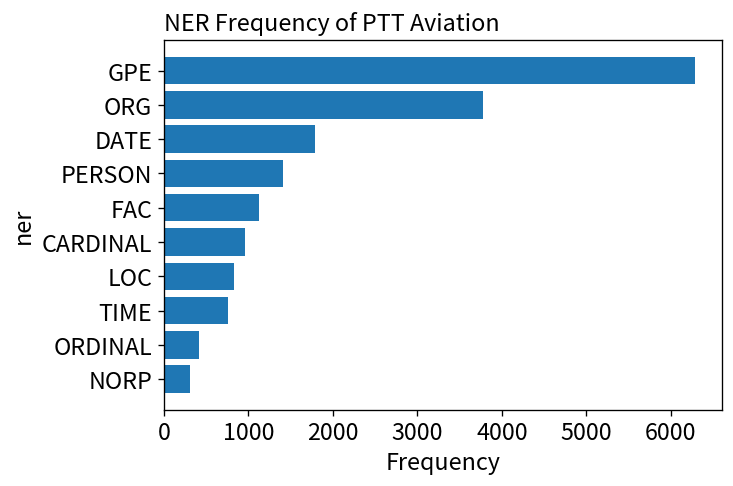

In [ ]:
ner = ner_count['ner']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(6, 4))
ax.barh(ner, count)
ax.invert_yaxis()
ax.set_title('NER Frequency of PTT Aviation',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
# fig.show()

Text(0.5, 0, 'Word Frequency')

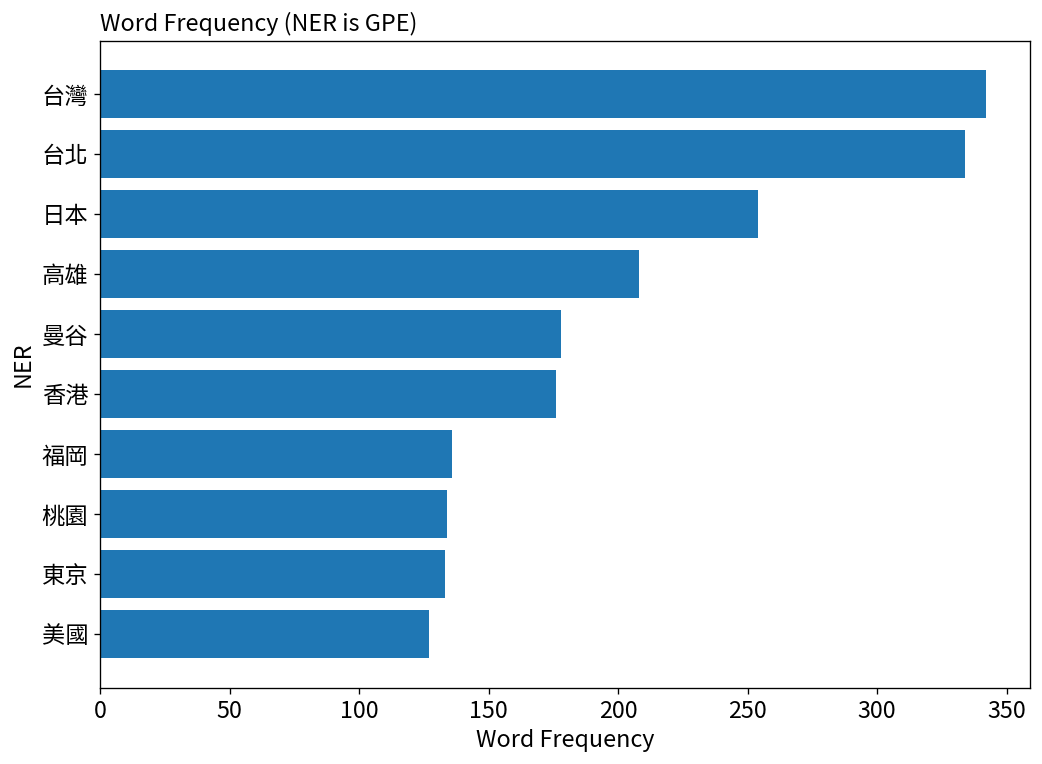

In [ ]:
# 篩選ner為GPE(行政區)的資料
l_noun = ["GPE"]
NORP = entity_table[entity_table.ner.isin(l_noun)]

ner_count = NORP.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(10).reset_index()
ner_count

word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is GPE)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

Text(0.5, 0, 'Word Frequency')

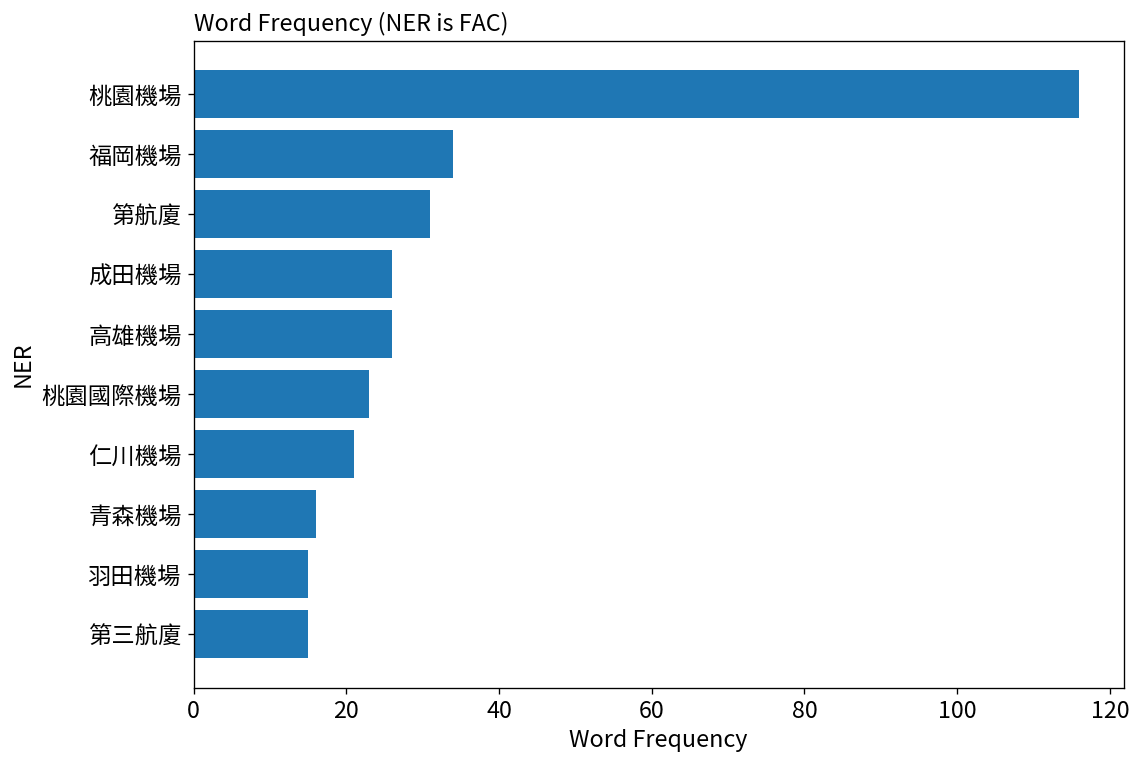

In [ ]:
# 篩選ner為FAC(設施)的資料
l_noun = ["FAC"]
ORG = entity_table[entity_table.ner.isin(l_noun)]

# # 計算每個名詞提到的次數，選出前10個
ner_count = ORG.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(10).reset_index()
ner_count

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is FAC)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

Text(0.5, 0, 'Word Frequency')

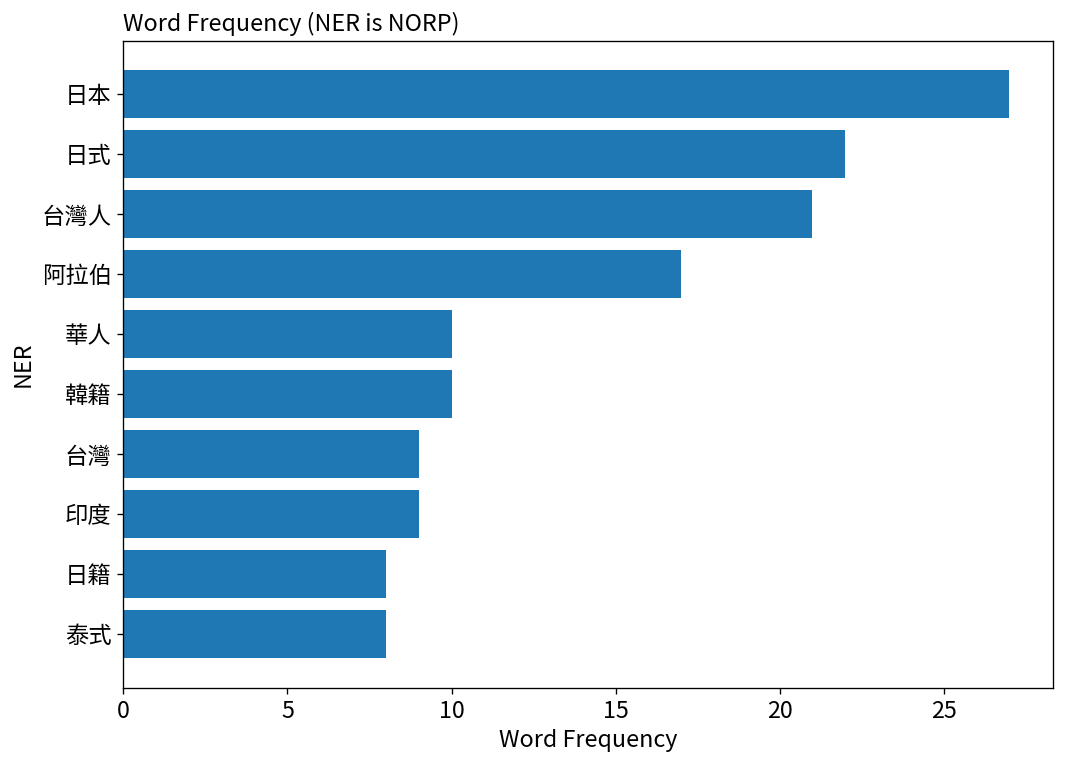

In [ ]:
# 篩選ner為NORP(民族、宗教、政治團體)的資料
l_noun = ["NORP"]
ORG = entity_table[entity_table.ner.isin(l_noun)]

# # 計算每個名詞提到的次數，選出前10個
ner_count = ORG.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(10).reset_index()
ner_count

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is NORP)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

In [ ]:
keyword_list = ['日本','日式']
shu_selected = df[df['artContent'].str.contains('|'.join(keyword_list),regex=True)]
print(f"{' '.join(keyword_list)}：{shu_selected.shape[0]}篇相關貼文")
shu_selected.head(3)

日本 日式：119篇相關貼文


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
6,7,https://www.ptt.cc/bbs/Aviation/M.1736266155.A...,[新聞]桃機出發日本特定機場1/16至2/12開放預,2025-01-08 00:09:13,mife103,Aviation,自由 1/7\n桃機出發日本特定機場 1/16至2/12開放預先清關\n因應春節及寒假人潮，...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""TsukimiyaAyu...",37.222.201.34,2025-01-08 01:00:43,ptt
8,9,https://www.ptt.cc/bbs/Aviation/M.1736519693.A...,[新聞]七大新航線揭幕！許智傑率交通部團隊考,2025-01-10 22:34:50,KW96,Aviation,七大新航線揭幕！許智傑率交通部團隊 考察高雄重大交通建設\n\n2025年1月9日 台灣好報...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""william8403""...",111.248.82.150,2025-01-11 01:00:43,ptt
11,12,https://www.ptt.cc/bbs/Aviation/M.1736665489.A...,[分享]日本捷星航空旭川-東京成田,2025-01-12 15:04:45,vhygdih,Aviation,完整圖文介紹:\nhttps://pse.is/6yhuzj\n日本捷星航空 旭川-東京成田...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""abian746"", ""...",219.70.33.96,2025-01-13 01:00:44,ptt


### 4.4 探索分析 - POS

詞性標記

In [ ]:
pos_table['pos'].unique()

array(['FW', 'Na', 'VH', 'VJ', 'D', 'VHC', 'Cbb', 'DE', 'SHI', 'Nd', 'Da',
       'Nh', 'Neqa', 'Nf', 'Nc', 'VA', 'Nes', 'Neu', 'VC', 'Nb', 'VE',
       'VL', 'VK', 'Cba', 'COMMACATEGORY', 'VG', 'P', 'VF', 'VB', 'Dk',
       'Nep', 'Ng', 'VCL', 'Ncd', 'Dfa', 'VD', 'Cab', 'Caa', 'V_2', 'Di',
       'VAC', 'Nv', 'T', 'A', 'I', 'Dfb', 'VI', 'PARENTHESISCATEGORY',
       'Neqb', 'PERIODCATEGORY', 'DM', 'COLONCATEGORY'], dtype=object)

In [ ]:
pos_filter = pos_table[~pos_table.pos.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]

pos_count = pos_filter.groupby(['pos'])['pos'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count

,pos,count
15,Na,48266
5,D,22439
17,Nc,17832
35,VC,15974
41,VH,12279
6,DE,11394
29,P,8863
32,VA,8146
25,Nf,6173
4,Cbb,4707


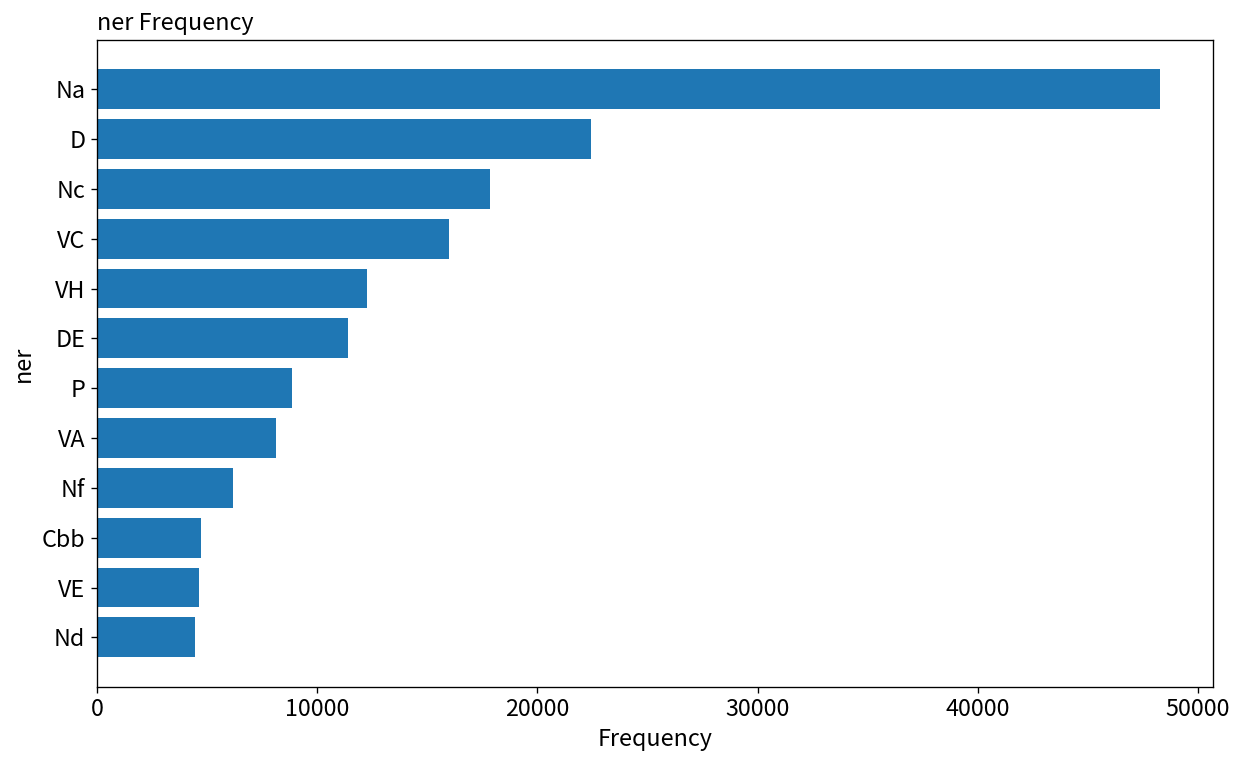

In [ ]:
pos = pos_count['pos']
count = pos_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(pos, count)
ax.invert_yaxis()
ax.set_title('ner Frequency',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
fig.show()

### 涉及到的名詞(Noun)

In [ ]:
# 篩選pos為專有名詞的資料
l_noun = ["Nb"]
noun = pos_table[pos_table.pos.isin(l_noun)]

noun_count = noun[['word']].groupby(['word'])['word'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(15)
noun_count.head(10)

,word,count
380,星宇,592
809,長榮,569
172,國泰,238
718,虎航,117
498,波音,94
636,羽田,75
865,韓亞,75
372,日航,62
471,樂桃,52
830,阿曼,52


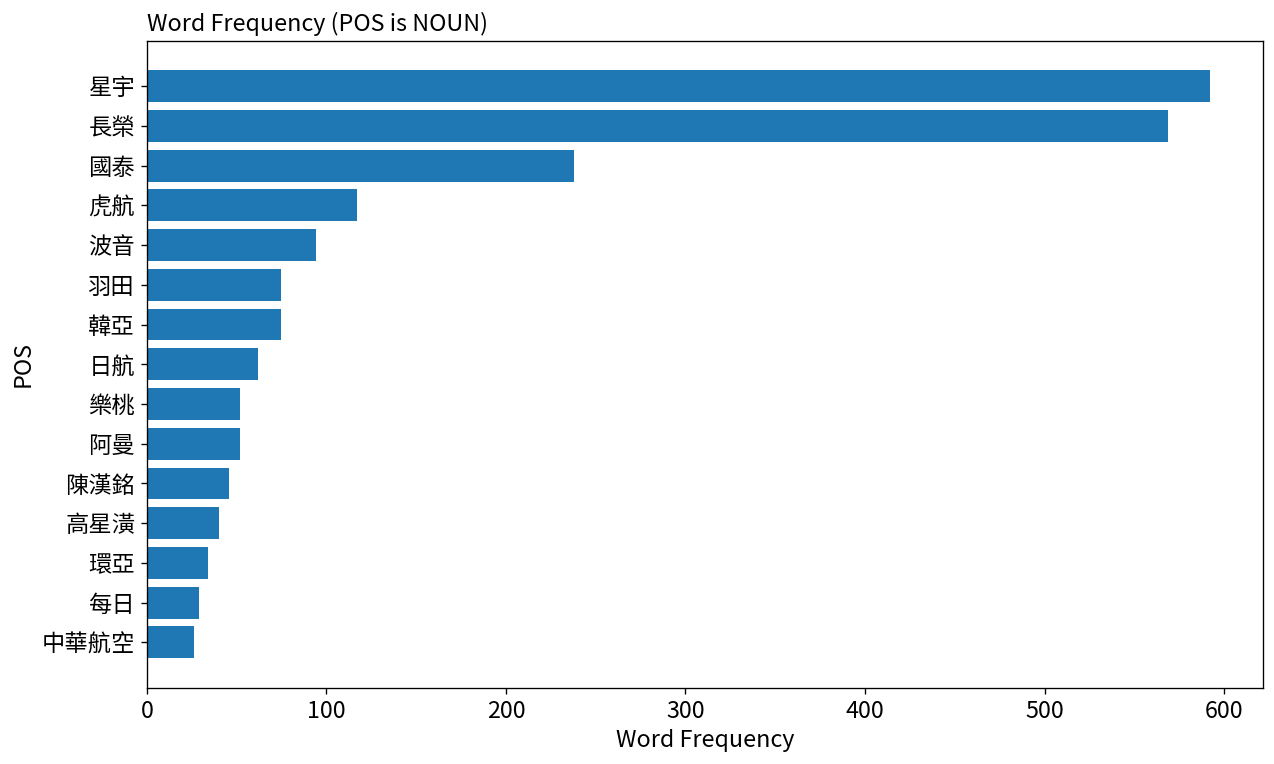

In [ ]:
# 設定中文字形
word = noun_count['word']
count = noun_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (POS is NOUN)',loc ='left', size = 14)
ax.set_ylabel('POS', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
fig.show()

### 涉及到的動詞

In [ ]:
l_verb = ["VC"] # ,"VH","VA"
verb = pos_table[pos_table.pos.isin(l_verb)]
verb = verb[verb['word'].map(len) > 1]

verb_count = verb[['word']].groupby(['word'])['word'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(15)
verb_count

,word,count
1125,服務,322
71,使用,322
928,搭乘,255
1902,選擇,206
472,完成,173
2079,體驗,156
941,搭配,130
1923,配置,113
1869,進行,101
300,取消,79


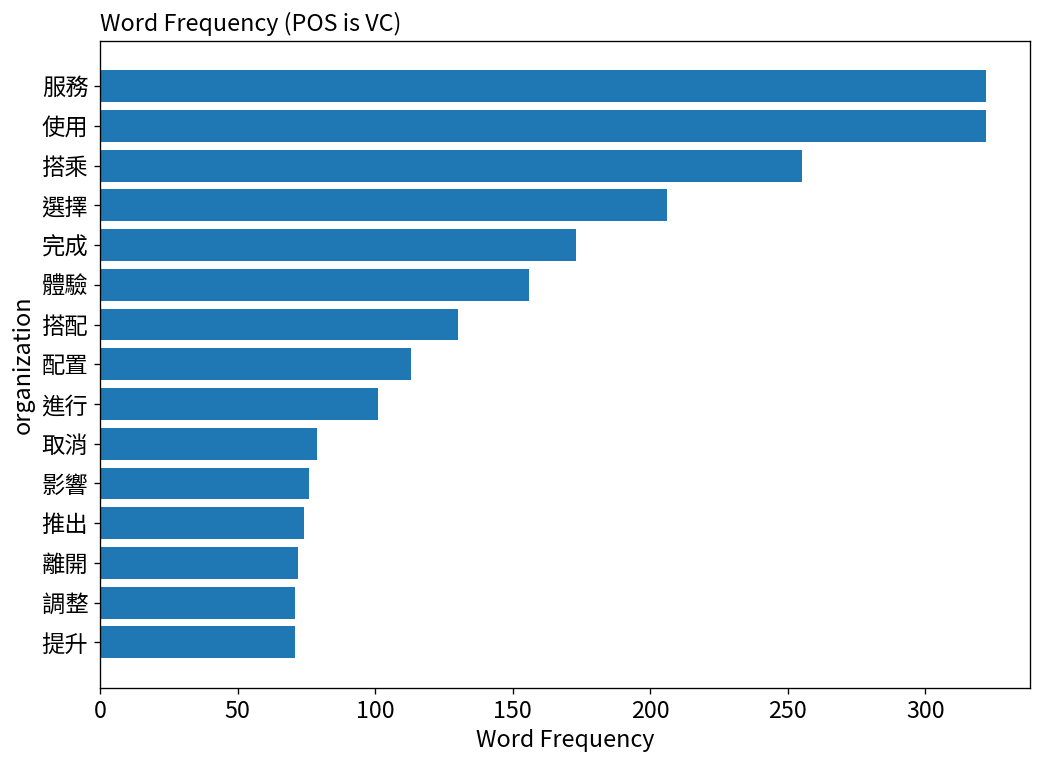

In [ ]:
word = verb_count['word']
count = verb_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (POS is VC)',loc ='left', size = 14)
ax.set_ylabel('organization', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
fig.show()

## 5. 利用SnowNLP進行情緒分析

In [ ]:
sentence_table = pd.read_csv("sentence_table_aviation.csv")

sentiment_date = pd.merge(sentence_table, shu_selected[['system_id','artDate','dataSource']], on='system_id', how='left').dropna()
sentiment_date = sentiment_date[sentiment_date['sentence'].str.contains('日本', na=False)]

sentiment_date.head()

,system_id,sentence,artDate,dataSource
223,7,桃機出發日本特定機場/至/開放預先清關,2025-01-08 00:09:13,ptt
226,7,日本與桃園國際機場於限定時段合作實,2025-01-08 00:09:13,ptt
232,7,前往日本特定機場的旅客,2025-01-08 00:09:13,ptt
236,7,可大幅縮短抵達日本機場後的通關審查作業時間,2025-01-08 00:09:13,ptt
238,7,今年再次與日本出入國在留管理廳合作台日機場入境事先確認,2025-01-08 00:09:13,ptt


In [ ]:
# 幫每句話加上情緒分數
from snownlp import SnowNLP
def get_sentiment(sent):
    s = SnowNLP(sent)
    return s.sentiments

sentiment_date['sentimentValue'] = sentiment_date.apply(lambda row : get_sentiment(row['sentence'],), axis = 1)
sentiment_date.head(10)

,system_id,sentence,artDate,dataSource,sentimentValue
223,7,桃機出發日本特定機場/至/開放預先清關,2025-01-08 00:09:13,ptt,0.860518
226,7,日本與桃園國際機場於限定時段合作實,2025-01-08 00:09:13,ptt,0.013859
232,7,前往日本特定機場的旅客,2025-01-08 00:09:13,ptt,0.086557
236,7,可大幅縮短抵達日本機場後的通關審查作業時間,2025-01-08 00:09:13,ptt,0.058595
238,7,今年再次與日本出入國在留管理廳合作台日機場入境事先確認,2025-01-08 00:09:13,ptt,0.004320
252,7,航空公司會提供宣傳單及日本入國紀錄,2025-01-08 00:09:13,ptt,0.178362
255,7,完成後可減少入境日本的境,2025-01-08 00:09:13,ptt,0.486442
258,7,台日機場入境事先確認由日本派遣審查官至桃機,2025-01-08 00:09:13,ptt,0.003002
263,7,旅客抵達日本,2025-01-08 00:09:13,ptt,0.932060
267,7,即可入境日本,2025-01-08 00:09:13,ptt,0.580564


In [ ]:
# 看情緒的分布
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sentiment_date['sentimentValue'].describe()

,sentimentValue
count,323.0000
mean,0.4011
std,0.3507
min,0.0000
25%,0.0587
50%,0.3218
75%,0.7475
max,0.9992


<Axes: >

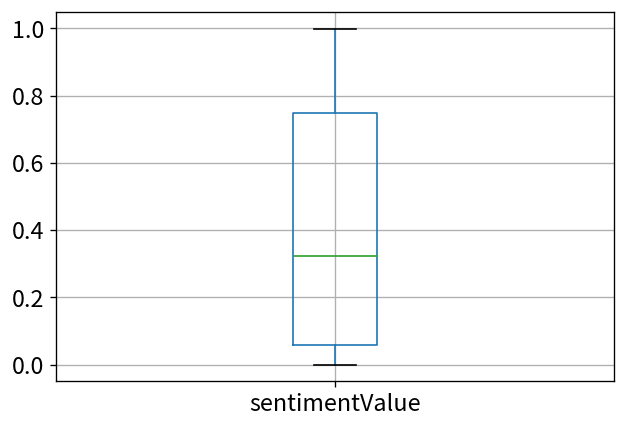

In [ ]:
# 情緒分布的盒狀圖
boxplot = sentiment_date.boxplot(column=['sentimentValue'], showfliers=False)
boxplot

In [ ]:
#抽出情緒分數<0.3的句子觀察
low_score_df = sentiment_date[sentiment_date['sentimentValue'] < 0.3]
low_score_df[['sentence', 'sentimentValue']].head(10)

,sentence,sentimentValue
226,日本與桃園國際機場於限定時段合作實,0.0139
232,前往日本特定機場的旅客,0.0866
236,可大幅縮短抵達日本機場後的通關審查作業時間,0.0586
238,今年再次與日本出入國在留管理廳合作台日機場入境事先確認,0.0043
252,航空公司會提供宣傳單及日本入國紀錄,0.1784
258,台日機場入境事先確認由日本派遣審查官至桃機,0.0030
273,旅客可出示手寫的日本入國紀錄卡,0.0454
587,"而且日本客運公車站都很漂亮乾淨,不會有破破爛爛感覺,",0.0002
589,"來日本這麼多次,",0.2736
597,本來以為日本的公車應該會很準時結果當天遲到了分鐘,0.0588


雖然情緒分數偏低，但從抽取出來的句子可以看到大多數都是描述性質的中性句子，因為沒有正面的字詞，因此被系統判定為負面

In [ ]:
# 計算平均情緒分數
sent_date = sentiment_date.copy()
sent_date['artDate'] =  pd.to_datetime(sentiment_date['artDate']).dt.to_period('M')

sentiment_count = sent_date.groupby(['artDate'])['sentimentValue'].mean().reset_index()
sentiment_count

,artDate,sentimentValue
0,2025-01,0.3806
1,2025-02,0.4113
2,2025-03,0.3968
3,2025-04,0.4159
4,2025-05,0.2783
5,2025-06,0.4856
6,2025-07,0.5268
7,2025-08,0.3934
8,2025-09,0.4274
9,2025-10,0.3361


/tmp/ipykernel_1038/945736703.py:7: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(months, y, linestyle='solid')


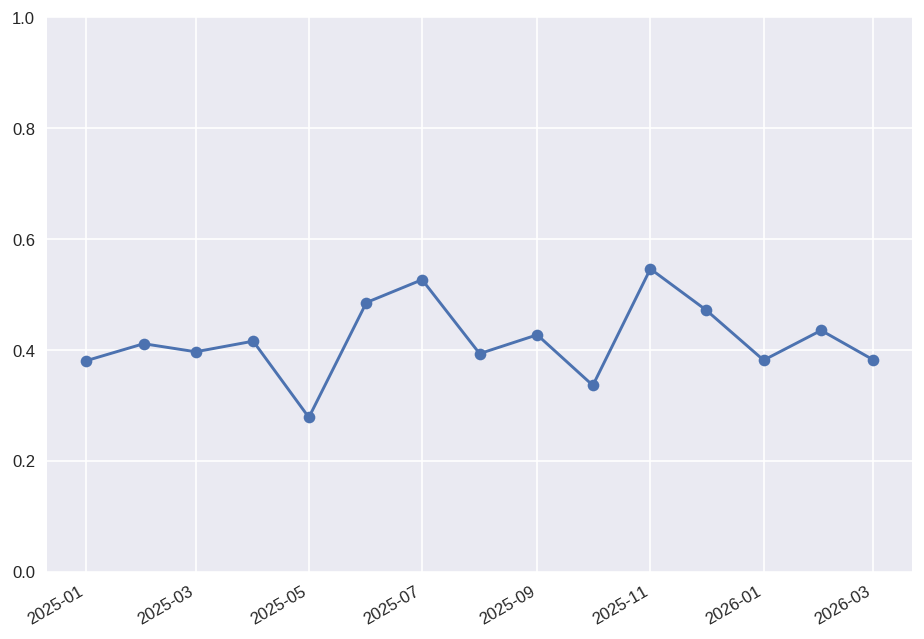

In [ ]:
# 平均情緒分數時間趨勢
months = [period.to_timestamp() for period in sentiment_count['artDate']]   # 將 PeriodIndex 中的每個 Period 物件轉換為對應的 datetime 物件
y = sentiment_count['sentimentValue']

plt.style.use('seaborn-v0_8')

plt.plot_date(months, y, linestyle='solid')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.ylim(0, 1)

plt.show()

In [ ]:
# 篩時間

filter_sentiment = sent_date[sent_date['artDate']=='2025-11']
filter_sentiment = filter_sentiment.loc[filter_sentiment['sentimentValue'] > 0.4]

filter_sentiment.head()

,system_id,sentence,artDate,dataSource,sentimentValue
31338,356,很適合飛虎航日本線吧,2025-11,ptt,0.7852
31460,358,"日本的民航法規允許在,以下可以觀看駕駛艙抬頭顯示儀模式",2025-11,ptt,0.8114
31618,358,來自人性的科技加上日本人的細膩,2025-11,ptt,0.9815
31627,358,的鶴丸是我到日本鄉下住晚的最佳旅伴,2025-11,ptt,0.5530
31768,363,上半年東協國家與中國日本及韓國的出口額同比增長,2025-11,ptt,0.7612


In [ ]:
# 把時間分數和之前斷詞的 token table 做 join
pos_words = pd.merge(filter_sentiment,pos_table,on='system_id',how='left')
pos_words = pos_words[['system_id','sentimentValue','word']]
pos_words.head()

,system_id,sentimentValue,word
0,356,0.7852,像
1,356,0.7852,虎航
2,356,0.7852,這
3,356,0.7852,種
4,356,0.7852,有


In [ ]:
pos_words = pos_words[pos_words.apply(lambda x: len(x['word'])>1, axis=1)]

In [ ]:
# 停用字
with open('stopwords.txt', encoding='utf-8') as f:
    stop_words = f.read().splitlines()

print(stop_words[:20])

['$', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', '_', '“', '”', '、', '。', '《', '》', '一']


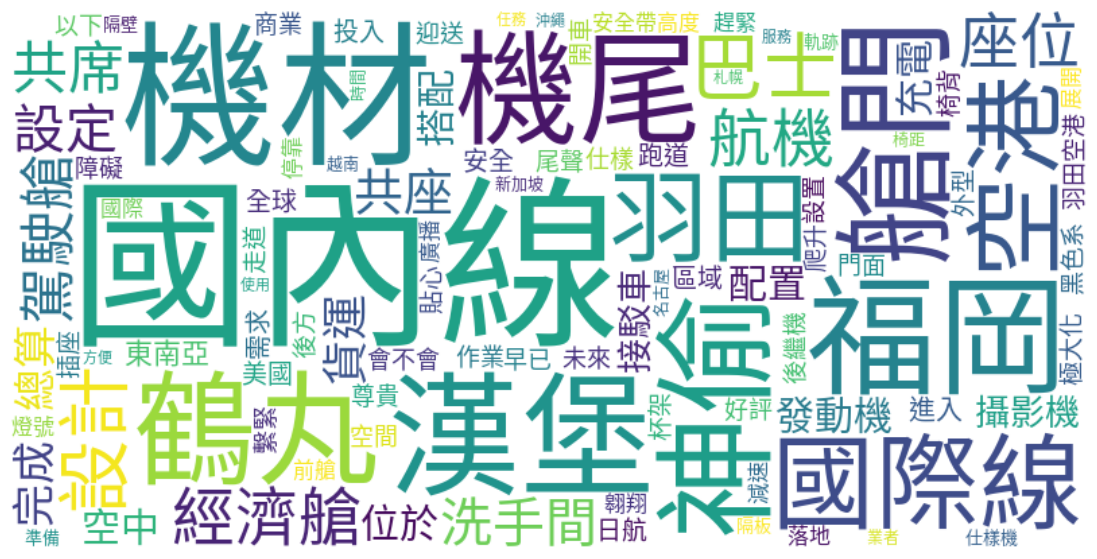

In [ ]:
# 自訂停用字
stop_words_pos = stop_words
stop_words_pos.extend(("虎航","確認","日本","航班", "班機", "飛機", "航線", "機場", "航廈", "飛行", "星宇", "今天", "最後","出發", "抵達", "起飛", "降落", "小時", "分鐘", "台灣", "台北", "桃園", "TPE", "公司", "每週", "長榮", "前往", "2025","登機", "報到", "櫃檯", "機票", "來回", "單程", "旅客", "客人","中華航空", "華航", "China", "Airlines", "CI", "航空"))
stop_words_pos = set(stop_words_pos)

font_path = 'SourceHanSansTW-Regular.otf'

wordcloud = WordCloud(
                stopwords=stop_words_pos,
                collocations=False,
                font_path=font_path,
                width=800,
                height = 400,
                max_words=100,
                background_color="white")

wordcloud.generate(' '.join(pos_words['word']))
# Display the generated image:
plt.figure(figsize = (14,7))
plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.show()

可從「福岡」、「羽田」等關鍵字看出，華航旅客可能大多前往日本福岡以及羽田旅遊。

## 6. 遇到的困難



*   即使在爬取資料時只選擇"中華航空"相關的關鍵字，許多文章中還是會同時出現其他航空的資訊，因此需要額外去除這些關鍵字。
*   在SnowNLP分析時發現情緒分數較低的句子不一定是"負面"，有可能是描述性質的句子，這些句子大部分會被系統判定為負面，因此需要多加留意。




